# Shor's algorithm in Qiskit: from the minimal circuit to the optimised ones

Factoring and the elliptic-curve discrete logarithm (ECDLP), built from scratch in `shor_qiskit/`,
explained as **products of unitaries**, costed in **qubits, Toffolis and T gates**, and run on
**Aer** at toy sizes, with every measured histogram set beside the exact distribution.

| part | what it shows |
|---|---|
| 0 | setup |
| 1 | the minimal factoring circuit, level by level: QFT → adder → modular adder → multiplier → order finding; run on Aer; post-processing |
| 2 | why it costs what it costs: qubit and gate counts derived from the circuit, checked against measurement |
| 3 | fault tolerance: Clifford+T, Solovay–Kitaev, and why a small phase shift costs ~100 T gates |
| 4 | the optimisations for factoring, each with its measured effect on qubits, Toffolis, T and rotations |
| 5 | the minimal ECDLP circuit, run on Aer |
| 6 | ECDLP complexity and optimisations |
| 7 | summary |

Every number below is computed here from the code: counts by `resources.count`, exact
distributions by `shor_stats`. The same claims are asserted by the test suite
(`./run_tests.sh fast`, `full`, `ec`), so the notebook cannot quietly disagree with it.

## 0. Setup

`resources.count(circuit)` walks a circuit, descending into composite gates such as `qft`,
and prices each primitive by its standard decomposition: a Toffoli is 7 T (4 as a temporary AND),
a controlled phase is two CNOTs and three single-qubit phases, and a phase shift is free,
1 T, or a **small-angle rotation** that has to be synthesised (part 3).

In [1]:
import math, pathlib, random, sys, time, warnings
from contextlib import contextmanager
from fractions import Fraction

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "shor_qiskit").is_dir())
sys.path[:0] = [str(ROOT / "shor_qiskit"), str(ROOT / "tests")]
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit import ControlledGate, Gate
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Operator
from qiskit.visualization import plot_distribution
from qiskit_aer import AerSimulator

import resources as R        # logical counts: qubits, Toffoli, T, rotations
import shor_stats as ST      # exact output distributions; TVD against shot noise

SIM = AerSimulator(seed_simulator=2026)


def sample(qc, shots=4096):
    # Sample a circuit on Aer.
    return SIM.run(transpile(qc, SIM, optimization_level=1), shots=shots).result().get_counts()


def exact_probs(qc, qubits):
    # Aer's exact output probabilities of `qubits` (final measurements removed).
    q = qc.remove_final_measurements(inplace=False)
    q.save_probabilities(list(qubits))
    return np.asarray(SIM.run(transpile(q, SIM, optimization_level=0)).result().data(0)["probabilities"])


def basis_out(qc):
    # The output basis state of a permutation circuit: one noiseless shot.
    m = qc.copy()
    m.measure_all()
    counts = SIM.run(transpile(m, SIM, optimization_level=0), shots=1).result().get_counts()
    return int(next(iter(counts)).replace(" ", ""), 2)


def box(label, nq, build):
    # A library builder wrapped as one labelled gate -- for drawing.
    sub = QuantumCircuit(nq)
    build(sub, list(sub.qubits))
    return sub.to_gate(label=label)


def cbox(label, n_ctrl, n_tgt, build):
    # A controlled library builder, drawn as control dots + a labelled box.  Its
    # definition IS the library circuit (controls first), so it simulates exactly.
    sub = QuantumCircuit(n_ctrl + n_tgt)
    build(sub, list(sub.qubits))
    return ControlledGate("cbox", n_ctrl + n_tgt, [], label=label, num_ctrl_qubits=n_ctrl,
                          definition=sub, base_gate=Gate("U", n_tgt, [], label=label))


def table(rows, headers):
    esc = lambda v: str(v).replace("|", "\\|")            # a bare | would split the cell
    fmt = lambda v: f"{v:,}" if isinstance(v, (int, np.integer)) else (f"{v:.3g}" if isinstance(v, float) else esc(v))
    out = ["| " + " | ".join(esc(h) for h in headers) + " |", "|" + "---|" * len(headers)]
    out += ["| " + " | ".join(fmt(v) for v in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))


COST = ["qubits", "Toffoli", "T (Toffoli = 7T)", "T (temporary AND)", "CP gates",
        "small rotations", "T incl. rotations (ε = 10⁻³)"]


def cost(label, qc, eps=1e-3):
    r = R.count(qc)
    q = f"{r.qubits} (+{r.ancillas})" if r.ancillas else r.qubits
    return [label, q, r.toffoli + r.and_, r.T, r.T_and, r.cphase, r.rotations, r.T_with_rotations(eps)]


def plot_order(theory, t, r, counts=None, title="", half=6):
    # One window per peak s·2^t/r: at 2^t outcomes the smeared peaks are too thin to see whole.
    q = 2**t
    emp = ST.empirical(counts, q) if counts else None
    fig, axes = plt.subplots(1, r, figsize=(2.0 * r, 2.5), sharey=True)
    for s, ax in enumerate(np.atleast_1d(axes)):
        c = s * q / r
        ys = np.arange(math.floor(c) - half, math.floor(c) + half + 2)
        if emp is not None:
            ax.bar(ys, emp[ys % q], width=0.8, color="tab:orange", alpha=0.7, label=f"Aer, {sum(counts.values())} shots")
        ax.plot(ys, theory[ys % q], "o-", ms=3, lw=1, color="tab:blue", label="exact")
        ax.axvline(c, color="gray", ls=":", lw=0.8)
        ax.set_title(f"s = {s}: y ≈ {c:.1f}", fontsize=9); ax.set_xlabel("y", fontsize=9)
    np.atleast_1d(axes)[0].set_ylabel("probability"); np.atleast_1d(axes)[-1].legend(fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()


def plot_pairs(exact, counts=None, title=""):
    q = exact.shape[0]
    panels = [("exact P(j₁, j₂)", exact)] + ([(f"Aer, {sum(counts.values())} shots", ST.empirical(counts, (q, q)))] if counts else [])
    fig, axes = plt.subplots(1, len(panels), figsize=(4.4 * len(panels), 3.6))
    for ax, (lab, M) in zip(np.atleast_1d(axes), panels):
        im = ax.imshow(M.T, origin="lower", cmap="viridis")
        ax.set_xlabel("j₁"); ax.set_ylabel("j₂"); ax.set_title(lab)
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title); plt.tight_layout(); plt.show()


print("repo:", ROOT)

repo: /Users/julian/shor


## 1. The minimal circuit for factoring

To factor $N$, pick a random $a$ coprime to $N$ and find its **order** $r$, the smallest $r>0$ with
$a^r\equiv 1 \pmod N$. If $r$ is even and $a^{r/2}\not\equiv-1$, then $\gcd(a^{r/2}\pm1,N)$ are
non-trivial factors. The quantum computer only finds $r$, by **phase estimation** of

$$U_a\,|x\rangle=|a x \bmod N\rangle,\qquad U_a|u_s\rangle=e^{2\pi i s/r}|u_s\rangle .$$

With $n=\lceil\log_2N\rceil$ and $t=2n$ counting qubits the whole algorithm is one product of
unitaries, read right to left:

$$U_{\text{Shor}}=\big(\mathrm{QFT}_{2^t}^{\dagger}\otimes I\big)\;\prod_{i=0}^{t-1}\Lambda_i\!\left(U_a^{2^i}\right)\;\big(H^{\otimes t}\otimes X_0\big)$$

where $\Lambda_i(U)$ is $U$ controlled by counting qubit $i$, and $U_a^{2^i}=U_{a^{2^i}\bmod N}$ is
computed classically. Everything else is arithmetic, in five levels, each a product of the one below:

| level | unitary | as a product of | code |
|---|---|---|---|
| 0 | $\mathrm{QFT}$ | $H$, controlled phases $\mathrm{CP}(\pi/2^d)$, SWAPs | `qft` |
| 1 | $\Phi\mathrm{ADD}(X):\ \lvert y\rangle\mapsto\lvert y+X \bmod 2^m\rangle$ | $\mathrm{QFT}^{\dagger}\,\cdot$ single-qubit phases $\cdot\,\mathrm{QFT}$ | `add_const` |
| 2 | $\mathrm{ADD}_N(X):\ \lvert y\rangle\mapsto\lvert y+X \bmod N\rangle$ | 5 adders + 2 flag gates (Beauregard) | `c_add_mod` |
| 3 | $\mathrm{CMULT}(a):\ \lvert x\rangle\lvert y\rangle\mapsto\lvert x\rangle\lvert y+ax \bmod N\rangle$ | $n$ doubly-controlled $\mathrm{ADD}_N(a2^i)$ | `c_mult_acc` |
| 4 | $\Lambda(U_a)$ | $\mathrm{CMULT}(a)$, controlled SWAP, $\mathrm{CMULT}(-a^{-1})$ | `c_ua` |
| 5 | $U_{\text{Shor}}$ | $t$ rungs + inverse QFT | `order_circuit` |

In [2]:
from shor_essentials import (add_const, c_add_const, c_add_mod, c_ua, find_factor,
                             order_circuit, order_from_counts, qft)

### 1.1 Level 0: the quantum Fourier transform

$\mathrm{QFT}_{2^n}|j\rangle=2^{-n/2}\sum_k e^{2\pi i jk/2^n}|k\rangle$. Writing $k=\sum_q k_q2^q$
turns the phase into a product, so the output is a **product state**. Output qubit $q$ is
$(|0\rangle+e^{2\pi i\,j2^q/2^n}|1\rangle)/\sqrt2$, and that phase depends only on the low bits of $j$.
One Hadamard produces the top bit's $\pm1$, and one controlled phase per lower bit adds the rest:

$$\mathrm{QFT}_{2^n}=\mathrm{SWAP}_{\text{rev}}\cdot B_0B_1\cdots B_{n-1},\qquad
B_j=\Big(\prod_{k<j}\mathrm{CP}_{k\to j}\big(\pi/2^{\,j-k}\big)\Big)\,H_j .$$

That is exactly the loop in `qft()`: **$n$ Hadamards, $n(n-1)/2$ controlled phases, $\lfloor n/2\rfloor$ swaps**.

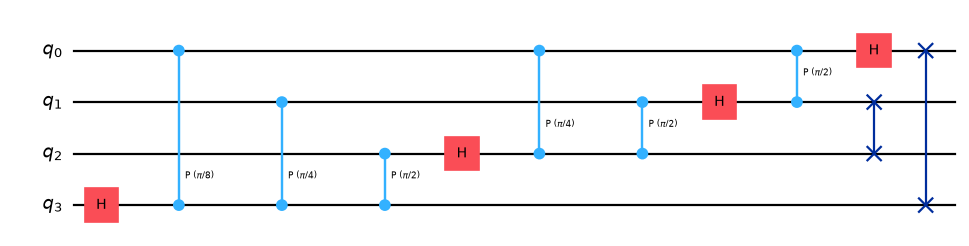

In [3]:
qc = QuantumCircuit(4)
qc.append(qft(4), range(4))
qc.decompose().draw("mpl", scale=0.8)

In [4]:
n = 4
dft = np.array([[np.exp(2j * np.pi * j * k / 2**n) for j in range(2**n)] for k in range(2**n)]) / 2 ** (n / 2)
print("qft(4) == the DFT matrix:     ", np.allclose(Operator(qft(n)).data, dft))
print("qft(4) == Qiskit's QFTGate(4):", Operator(qft(n)) == Operator(QFTGate(n)))

qft(4) == the DFT matrix:      True
qft(4) == Qiskit's QFTGate(4): True


### Why the swaps at the end?

The swaps undo a bit reversal that the Hadamard and controlled-phase loop produces on its own. Output
qubit $q$ (weight $2^q$) must carry the phase $e^{2\pi i\,j2^q/2^n}$, which depends only on the lowest
$n-q$ bits of $j$. So the output's *most* significant bit needs only $(-1)^{j_0}$, a function of the input's
*least* significant bit, while the output's least significant bit needs all of $j$.

The circuit works in place, top qubit first. Each qubit first lends its bit, as a control, to the qubits
above it. Then its own Hadamard turns it into a phase factor with its own bit as the leading binary digit,
$e^{2\pi i\,0.j_jj_{j-1}\cdots j_0}$. That is the factor for output weight $2^{\,n-1-j}$, so every factor
lands on the mirror-image qubit. (The factor $(-1)^{j_0}$ can only be built on qubit 0, where $j_0$ lives.)
The $\lfloor n/2\rfloor$ swaps put them back. For $n=3$ and input $|1\rangle$:

In [5]:
from qiskit.quantum_info import Statevector

def qft_noswap(n):
    # qft() without its final swaps
    qc = QuantumCircuit(n)
    for j in reversed(range(n)):
        qc.h(j)
        for k in range(j):
            qc.cp(np.pi / 2 ** (j - k), k, j)
    return qc

def phases(circ, j, n):
    # each output qubit is (|0> + e^{2πiφ}|1>)/√2: read φ off the amplitudes
    psi = Statevector.from_int(j, 2**n).evolve(circ).data
    return [f"{(np.angle(psi[1 << q] / psi[0]) / (2 * np.pi)) % 1:.3f}" for q in range(n)]

n, j = 3, 1
reverse = QuantumCircuit(n)
for i in range(n // 2):
    reverse.swap(i, n - 1 - i)
print("QFT == SWAP_rev · (the loop without swaps):",
      Operator(qft_noswap(n)).compose(Operator(reverse)) == Operator(QFTGate(n)))

with_swaps = QuantumCircuit(n); with_swaps.append(qft(n), range(n))
table([["required: j·2^q / 2^n", *[f"{j * 2**q / 2**n % 1:.3f}" for q in range(n)]],
       ["the loop without the swaps", *phases(qft_noswap(n), j, n)],
       ["qft(), with the swaps", *phases(with_swaps, j, n)]],
      [f"phase on each qubit (× 2π), input |{j}⟩", *[f"qubit {q} (weight 2^{q})" for q in range(n)]])

QFT == SWAP_rev · (the loop without swaps): True


| phase on each qubit (× 2π), input \|1⟩ | qubit 0 (weight 2^0) | qubit 1 (weight 2^1) | qubit 2 (weight 2^2) |
|---|---|---|---|
| required: j·2^q / 2^n | 0.125 | 0.250 | 0.500 |
| the loop without the swaps | 0.500 | 0.250 | 0.125 |
| qft(), with the swaps | 0.125 | 0.250 | 0.500 |

The swaps are bookkeeping, so they can usually be absorbed into a relabelling instead of executed.
Inside the Draper adder of §1.2, the swaps at the end of $\mathrm{QFT}$ and at the start of
$\mathrm{QFT}^\dagger$ cancel once the phase for weight $2^i$ goes on qubit $n-1-i$:

swap-free QFTs + relabelled phase layer == add_const(3): True


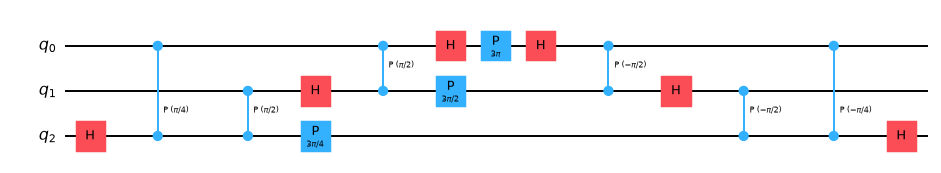

order_circuit(7, 15) executes 1,284 swaps: 3,852 of its 17,988 CNOTs (21%), and 0 T gates


In [6]:
X = 3
swap_free = qft_noswap(n)
for i in range(n):
    swap_free.p(2 * np.pi * X * 2.0 ** (i - n), n - 1 - i)     # phase for weight 2^i on qubit n-1-i
swap_free = swap_free.compose(qft_noswap(n).inverse())
adder = QuantumCircuit(n); add_const(adder, X, list(adder.qubits))
print("swap-free QFTs + relabelled phase layer == add_const(3):", Operator(swap_free) == Operator(adder))
display(swap_free.draw("mpl", scale=0.7))

def count_swaps(circ):
    total = 0
    for inst in circ.data:
        if inst.operation.name == "swap":
            total += 1
        elif inst.operation.name in ("qft", "qft_dg"):
            total += count_swaps(inst.operation.definition)
    return total

sw, cx = count_swaps(order_circuit(7, 15)), R.count(order_circuit(7, 15)).cx
print(f"order_circuit(7, 15) executes {sw:,} swaps: {3 * sw:,} of its {cx:,} CNOTs ({3 * sw / cx:.0%}), and 0 T gates")

A swap costs 3 CNOTs and no T gates, so dropping them changes none of the fault-tolerant counts in part 2.
It does save CNOTs, and in three places the reversal costs nothing at all:

* **before a measurement**, as at the end of Shor's circuit: measure qubit $i$ into classical bit $t-1-i$;
* **inside an adder**, as above. `qft()` keeps its swaps so that it equals `QFTGate` and the textbook
  definition exactly, which is why every adder here carries $2\lfloor m/2\rfloor$ swaps it doesn't need;
* **in the semiclassical QFT** (§4.9) there are none: running the heaviest rung first and writing
  measurement $i$ into bit $i$ performs the reversal for free.

**What a controlled phase is made of.** $\mathrm{CP}(\theta)$ decomposes into two CNOTs and
three single-qubit phases $P(\pm\theta/2)$:

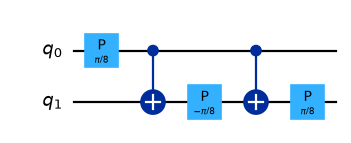

| n | H | CP = n(n−1)/2 | of which CP(π/2) = CS | CP(π/2^d), d ≥ 2 | T (exact part) | small-angle rotations |
|---|---|---|---|---|---|---|
| 4 | 4 | 6 | 3 | 3 | 9 | 9 |
| 8 | 8 | 28 | 7 | 21 | 21 | 63 |
| 16 | 16 | 120 | 15 | 105 | 45 | 315 |
| 32 | 32 | 496 | 31 | 465 | 93 | 1,392 |

In [7]:
cp = QuantumCircuit(2)
cp.cp(np.pi / 4, 0, 1)
display(transpile(cp, basis_gates=["p", "cx"], optimization_level=0).draw("mpl", scale=0.8))

rows = []
for n in (4, 8, 16, 32):
    q = QuantumCircuit(n); q.append(qft(n), range(n)); r = R.count(q)
    rows.append([n, r.h, r.cphase, n - 1, r.cphase - (n - 1), r.T, r.rotations])
table(rows, ["n", "H", "CP = n(n−1)/2", "of which CP(π/2) = CS", "CP(π/2^d), d ≥ 2", "T (exact part)", "small-angle rotations"])

$P(\pi)=Z$, $P(\pi/2)=S$ and $P(\pi/4)=T$ belong to the fault-tolerant gate set, so
$\mathrm{CP}(\pi/2)=\mathrm{CS}$ costs exactly 3 T. Every $\mathrm{CP}(\pi/2^d)$ with $d\ge2$ contains
phases $P(\pi/2^{d+1})$ that are **not** in the gate set and have to be approximated (part 3).
That is $3\cdot\binom{n-1}{2}$ small rotations per QFT, and the approximate QFT (§4.2) is the
standard way to cut them.

### 1.2 Level 1: Draper's adder, where addition is a phase in Fourier space

In the Fourier basis, qubit $i$ of $\mathrm{QFT}|y\rangle$ carries the phase $e^{2\pi i\,y2^i/2^m}$.
Adding a classical $X$ multiplies it by $e^{2\pi i\,X2^i/2^m}$. That is one single-qubit phase gate
per qubit, with **no carries**:

$$\Phi\mathrm{ADD}(X)=\mathrm{QFT}^{\dagger}\Big(\bigotimes_{i=0}^{m-1}P\big(2\pi X2^{i}/2^{m}\big)\Big)\,\mathrm{QFT}.$$

The cost is two $\mathrm{QFT}_m$ plus $m$ phases. The controlled adder only needs the phases
controlled, because the QFT pair cancels when they don't fire.

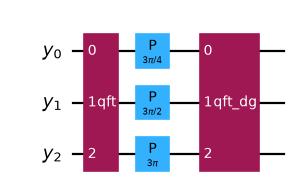

ΦADD(3) == the cyclic shift |y> -> |y+3 mod 8>: True


In [8]:
qc = QuantumCircuit(QuantumRegister(3, "y"))
add_const(qc, 3, list(qc.qubits))
display(qc.draw("mpl", scale=0.8))
shift = np.roll(np.eye(8), 3, axis=0)               # |y> -> |y + 3 mod 8>
print("ΦADD(3) == the cyclic shift |y> -> |y+3 mod 8>:", np.allclose(Operator(qc).data, shift))

### 1.3 Level 2: Beauregard's modular adder

$y+X$ may overflow $N$. Beauregard reduces it with seven blocks on the $(n{+}1)$-bit register
$y\,\|\,\text{sign}$ plus one flag qubit (right to left):

$$\mathrm{ADD}_N(X)=\underbrace{\Phi(X)}_{7}\;\underbrace{X_f\,\Lambda_{c,s}(X_f)}_{6}\;\underbrace{\Phi(-X)}_{5}\;\underbrace{\Lambda_f\,\Phi(N)}_{4}\;\underbrace{\mathrm{CX}_{s\to f}}_{3}\;\underbrace{\Phi(-N)}_{2}\;\underbrace{\Lambda_c\,\Phi(X)}_{1}$$

The steps: (1) add $X$ (controlled); (2) subtract $N$; (3) copy the sign bit (did it go negative?) into
the flag; (4) add $N$ back if so; (5)–(7) subtract $X$ so the sign bit reveals the flag, clear the flag,
and add $X$ again. Only blocks (1) and (6) carry the outer controls; the rest cancel in pairs when
the controls are off (§4.1). Built block by block from the library pieces, the product equals `c_add_mod`:

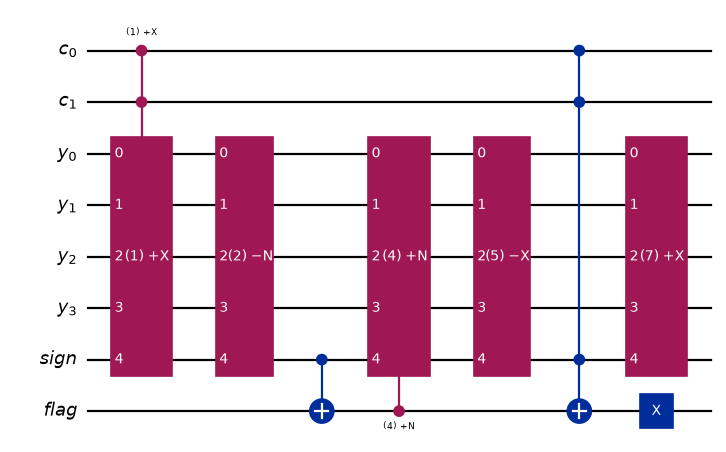

the seven blocks == c_add_mod: True


y            : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
(y + 7) mod 15: [7, 8, 9, 10, 11, 12, 13, 14, 0, 1, 2, 3, 4, 5, 6]  sign/flag back to 0: True


In [9]:
N, X, n = 15, 7, 4
c, y, s, f = QuantumRegister(2, "c"), QuantumRegister(n, "y"), QuantumRegister(1, "sign"), QuantumRegister(1, "flag")
yw = [*y, s[0]]; m = len(yw)
blocks = QuantumCircuit(c, y, s, f)
blocks.append(cbox("(1) +X", 2, m, lambda q, b: c_add_const(q, b[:2], X, b[2:])), [*c, *yw])
blocks.append(box("(2) −N", m, lambda q, b: add_const(q, -N, b)), yw)
blocks.cx(s[0], f[0])                                                   # (3)
blocks.append(cbox("(4) +N", 1, m, lambda q, b: c_add_const(q, b[:1], N, b[1:])), [f[0], *yw])
blocks.append(box("(5) −X", m, lambda q, b: add_const(q, -X, b)), yw)
blocks.mcx([*c, s[0]], f[0]); blocks.x(f[0])                            # (6)
blocks.append(box("(7) +X", m, lambda q, b: add_const(q, X, b)), yw)
display(blocks.draw("mpl", scale=0.8))

lib = QuantumCircuit(c, y, s, f)
c_add_mod(lib, list(c), X, list(y), s[0], f[0], N)
print("the seven blocks == c_add_mod:", Operator(blocks) == Operator(lib))

outs = []
for y0 in range(N):                                                     # both controls on
    q = QuantumCircuit(c, y, s, f); q.x(c)
    for i in range(n):
        if (y0 >> i) & 1: q.x(y[i])
    c_add_mod(q, list(c), X, list(y), s[0], f[0], N)
    v = basis_out(q)
    outs.append(((v >> 2) & 15, v >> 6))
print("y            :", list(range(N)))
print("(y + 7) mod 15:", [o for o, _ in outs], " sign/flag back to 0:", all(fl == 0 for _, fl in outs))

### 1.4 Levels 3–4: multiplication, and the controlled $U_a$

Multiplying by a constant is shift-and-add, $ax=\sum_i x_i\,(a2^i)$:

$$\mathrm{CMULT}(a)=\prod_{i=0}^{n-1}\Lambda_{c,x_i}\!\big(\mathrm{ADD}_N(a2^i\bmod N)\big):\quad|c\rangle|x\rangle|0\rangle\mapsto|c\rangle|x\rangle|c\cdot ax\bmod N\rangle .$$

That is out of place. Phase estimation needs $U_a$ **in place**, so multiply, swap, and
un-multiply by the inverse:

$$\Lambda_c(U_a)=\mathrm{CMULT}(-a^{-1})\cdot\Lambda_c\big(\mathrm{SWAP}^{\otimes n}\big)\cdot\mathrm{CMULT}(a):\quad
|x\rangle|0\rangle\to|x\rangle|ax\rangle\to|ax\rangle|x\rangle\to|ax\rangle|x-a^{-1}ax\rangle=|ax\rangle|0\rangle .$$

One rung is therefore **$2n$ modular additions and $n$ controlled swaps**.

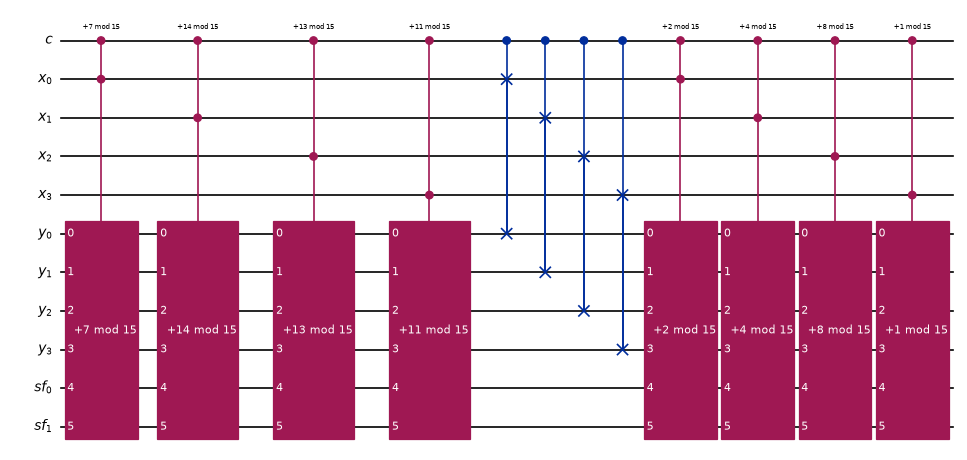

blocks and library c_ua both map |x>|0> -> |7x mod 15>|0> for every x: True


In [10]:
N, A, n = 15, 7, 4
B = pow(A, -1, N)
cc, x, yy, sf = QuantumRegister(1, "c"), QuantumRegister(n, "x"), QuantumRegister(n, "y"), QuantumRegister(2, "sf")
rung = QuantumCircuit(cc, x, yy, sf)
for k, mult in enumerate((A, (-B) % N)):
    if k == 1:
        for i in range(n):
            rung.cswap(cc[0], x[i], yy[i])
    for i in range(n):
        v = (mult << i) % N
        rung.append(cbox(f"+{v} mod {N}", 2, n + 2,
                         lambda q, b, v=v: c_add_mod(q, b[:2], v, b[2:2 + n], b[-2], b[-1], N)),
                    [cc[0], x[i], *yy, *sf])
display(rung.draw("mpl", scale=0.6, fold=-1))

ok = True
for x0 in range(1, N):
    for circ in (rung, None):
        q = QuantumCircuit(cc, x, yy, sf); q.x(cc[0])
        for i in range(n):
            if (x0 >> i) & 1: q.x(x[i])
        if circ is None:
            c_ua(q, cc[0], A, list(x), list(yy), sf[0], sf[1], N)
        else:
            q.compose(circ, inplace=True)
        v = basis_out(q)
        ok &= (v >> 1) & 15 == A * x0 % N and v >> 5 == 0
print(f"blocks and library c_ua both map |x>|0> -> |7x mod 15>|0> for every x: {ok}")

### 1.5 Level 5: order finding, run on Aer

With the rungs drawn as boxes, the circuit is exactly the product formula above, on
$t+n+n+2=4n+2=18$ qubits:

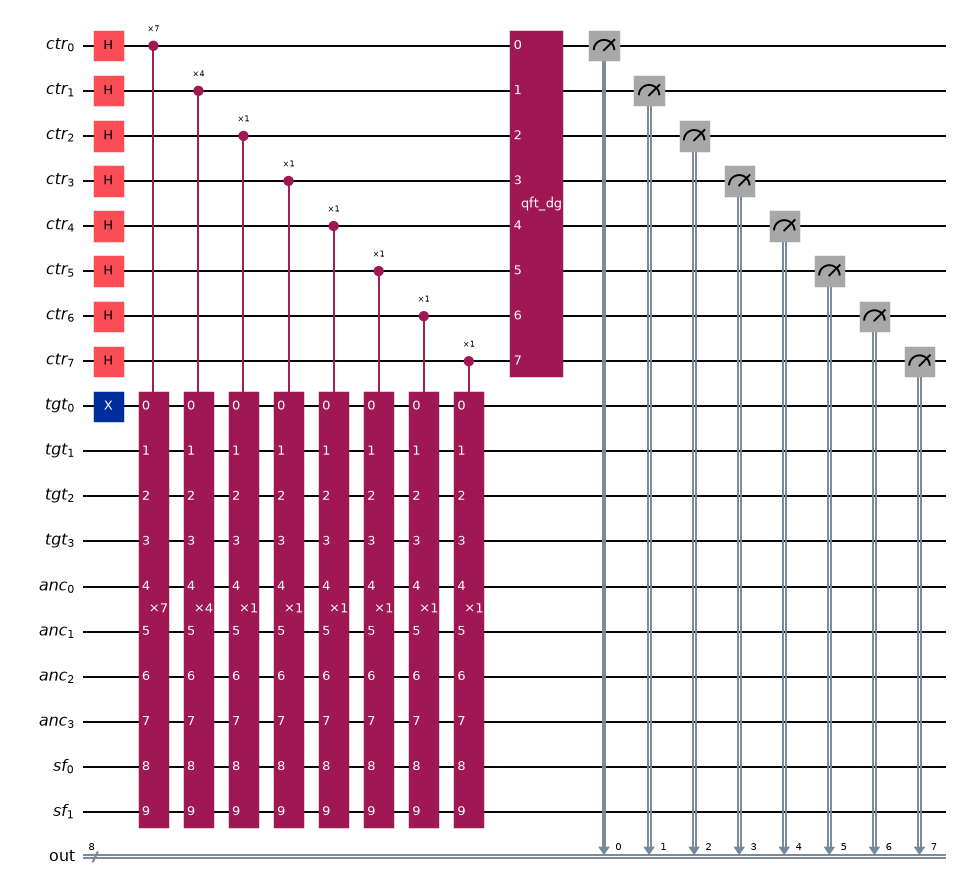

In [11]:
def boxed_order_circuit(A, N):
    n = math.ceil(math.log2(N)); t = 2 * n
    ctr, tgt, anc, sf = QuantumRegister(t, "ctr"), QuantumRegister(n, "tgt"), QuantumRegister(n, "anc"), QuantumRegister(2, "sf")
    qc = QuantumCircuit(ctr, tgt, anc, sf, ClassicalRegister(t, "out"))
    qc.h(ctr); qc.x(tgt[0])
    for i in range(t):
        a = pow(A, 2**i, N)
        qc.append(cbox(f"×{a}", 1, 2 * n + 2,
                       lambda q, b, a=a: c_ua(q, b[0], a, b[1:1 + n], b[1 + n:1 + 2 * n], b[-2], b[-1], N)),
                  [ctr[i], *tgt, *anc, *sf])
    qc.append(qft(t).inverse(), ctr)
    qc.measure(ctr, qc.cregs[0])
    return qc

boxed_order_circuit(7, 15).draw("mpl", scale=0.7, fold=-1)

Six of the eight rungs multiply by $7^{2^i}\equiv1 \pmod{15}$ for $i\ge2$, because $r=4$. Removing them would
be the "compiled" Shor of early experiments, which uses the answer to build the circuit. The circuit here
does not: every rung is the full controlled multiplier, since in general $r$ is unknown.

Now the real circuit (`order_circuit`, with every gate expanded) on Aer. The **exact** output
distribution has a closed form, derived in `shor_stats`: the target register takes $r$ distinct
values, one per residue $x_0=x \bmod r$, so

$$P(y)=4^{-t}\sum_{x_0<r}\Big|\sum_{m<M(x_0)}e^{-2\pi i\,m r y/2^t}\Big|^2,\qquad M(x_0)=\Big\lceil\frac{2^t-x_0}{r}\Big\rceil .$$

Three things are compared: that closed form, Aer's exact statevector probabilities, and the
sampled histogram (whose distance from the exact one should be within shot noise).

18 qubits; Aer: 1.9s for 4096 shots


Aer's exact probabilities == closed form: True
TVD(measured, exact) = 0.0063   shot-noise bound (99.99%) = 0.0317


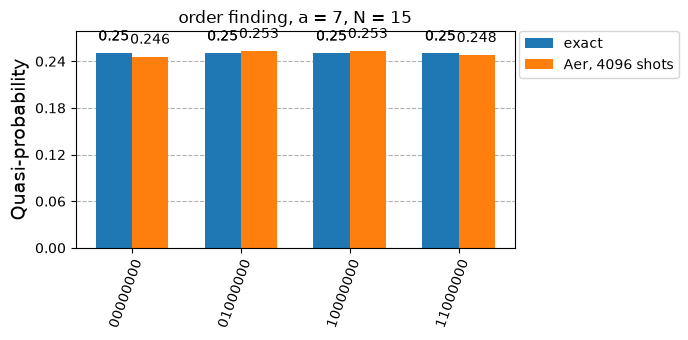

In [12]:
N, A, t = 15, 7, 8
qc = order_circuit(A, N)
t0 = time.time(); counts = sample(qc, 4096); dt = time.time() - t0
theory = ST.order_finding_probs(A, N, t)
print(f"{qc.num_qubits} qubits; Aer: {dt:.1f}s for 4096 shots")
print("Aer's exact probabilities == closed form:", np.allclose(exact_probs(qc, range(t)), theory))
measured = ST.order_counts(counts)
emp = ST.empirical(measured, 2**t)
print(f"TVD(measured, exact) = {ST.tvd(emp, theory):.4f}   shot-noise bound (99.99%) = {ST.tvd_null(theory, 4096):.4f}")
plot_distribution([{format(y, "08b"): p for y, p in enumerate(theory) if p > 1e-9}, counts],
                  legend=["exact", "Aer, 4096 shots"], title="order finding, a = 7, N = 15", figsize=(7, 3.5))

**Classical post-processing.** Each peak $y$ approximates $s/r\cdot2^t$. Continued fractions give $s/r$
in lowest terms, and $r$ is its denominator whenever $\gcd(s,r)=1$:

In [13]:
rows = []
for y, cnt in sorted(measured.items(), key=lambda kv: -kv[1]):
    fr = Fraction(y, 2**t).limit_denominator(N - 1)
    rows.append([y, cnt, f"{y}/{2**t}", f"{fr.numerator}/{fr.denominator}", fr.denominator,
                 "yes" if pow(A, fr.denominator, N) == 1 else "no"])
table(rows, ["y", "shots", "y / 2^t", "continued fraction s/r", "candidate r", "a^r ≡ 1 ?"])
hit = ST.order_success_mask(A, N, t)
print(f"one shot yields r: P = {theory[hit].sum():.3f} exact, {emp[hit].sum():.3f} measured")
r = order_from_counts(counts, A, N, t)
print(f"r = {r};  gcd(7^2 - 1, 15) = {math.gcd(A**(r//2) - 1, N)},  gcd(7^2 + 1, 15) = {math.gcd(A**(r//2) + 1, N)}")

random.seed(3)
print("find_factor(15), end to end with random bases:", find_factor(15, lambda q: sample(q, 512)))

| y | shots | y / 2^t | continued fraction s/r | candidate r | a^r ≡ 1 ? |
|---|---|---|---|---|---|
| 64 | 1,037 | 64/256 | 1/4 | 4 | yes |
| 128 | 1,037 | 128/256 | 1/2 | 2 | no |
| 192 | 1,015 | 192/256 | 3/4 | 4 | yes |
| 0 | 1,007 | 0/256 | 0/1 | 1 | no |

one shot yields r: P = 0.500 exact, 0.501 measured
r = 4;  gcd(7^2 - 1, 15) = 3,  gcd(7^2 + 1, 15) = 5
find_factor(15), end to end with random bases: 5


### 1.6 When $r$ does not divide $2^t$

For $N=15$ every order divides $2^8$, so the peaks are sharp. For $N=21$, $a=2$ the order is $r=6$,
the peaks smear, and only some outcomes give $r$. That is why $t=2n$. Legendre's theorem guarantees
that continued fractions recover $s/r$ when $|y/2^t-s/r|<1/(2r^2)$, which $2^t\ge N^2$ ensures for the
nearest $y$. The Aer run for $N=21$ is in §4.9, on the one-counting-qubit circuit.

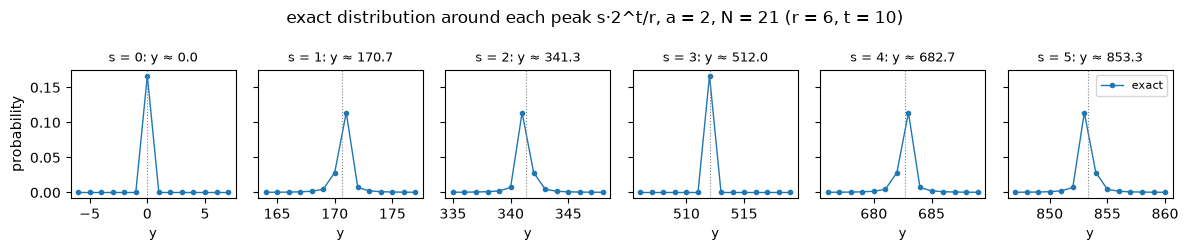

P(one shot yields r = 6) = 0.322; P(y lands within ±1 of a peak) = 0.932


In [14]:
theory21 = ST.order_finding_probs(2, 21, 10)
hit21 = ST.order_success_mask(2, 21, 10)
plot_order(theory21, 10, 6, title="exact distribution around each peak s·2^t/r, a = 2, N = 21 (r = 6, t = 10)")
print(f"P(one shot yields r = 6) = {theory21[hit21].sum():.3f}; "
      f"P(y lands within ±1 of a peak) = {sum(theory21[round(s * 1024 / 6 + d) % 1024] for s in range(6) for d in (-1, 0, 1)):.3f}")

## 2. Why it costs what it costs

Everything is determined by the composition in part 1. With $n=\lceil\log_2N\rceil$, $m=n+1$ (the adder
width: value and sign) and $t=2n$:

| object | qubits | Toffoli | controlled phases (CP) |
|---|---|---|---|
| $\mathrm{QFT}_m$ | $m$ | 0 | $m(m-1)/2$ |
| $\Lambda_{c,x_i}\mathrm{ADD}_N$: 10 $\mathrm{QFT}_m$, $m$ doubly-controlled phases, 1 $C^3X$ | $n+4$ | $2m+3$ | $5m(m-1)+2m$ |
| one rung $\Lambda(U_a)$: $2n$ $\mathrm{ADD}_N$ + $n$ CSWAP | $2n+3$ | $4n^2+11n$ | $2n\,(5m(m-1)+2m)$ |
| $U_{\text{Shor}}$: $t=2n$ rungs + $\mathrm{QFT}_t^{\dagger}$ | $\mathbf{4n+2}$ | $\mathbf{8n^3+22n^2}$ | $4n^2(5m(m-1)+2m)+t(t-1)/2\approx\mathbf{20n^4}$ |

The Toffolis come from the multiply-controlled gates: a doubly-controlled phase is 2 Toffolis around a
CP, and a $C^3X$ is 3 Toffolis. So Beauregard's circuit is $O(n^3)$ Toffolis but **$O(n^4)$ small
rotations**, and part 3 shows each rotation costs tens of T gates. The table checks every formula
against the gates actually built, up to $n=8$:

In [15]:
rows, data = [], []
for n, N in ((4, 15), (5, 21), (6, 33), (7, 65), (8, 129)):
    t0 = time.time(); r = R.count(order_circuit(2, N)); dt = time.time() - t0
    m, t = n + 1, 2 * n
    cp_formula = 4 * n * n * (5 * m * (m - 1) + 2 * m) + t * (t - 1) // 2
    rows.append([n, N, r.qubits, 4 * n + 2, r.toffoli, 8 * n**3 + 22 * n**2, r.cphase, cp_formula,
                 r.rotations, r.T, r.T_with_rotations(1e-3)])
    data.append((n, r.toffoli, r.cphase, r.rotations))
table(rows, ["n", "N", "qubits", "4n+2", "Toffoli", "8n³+22n²", "CP", "formula", "small rotations",
             "T (exact part)", "T incl. rotations"])

| n | N | qubits | 4n+2 | Toffoli | 8n³+22n² | CP | formula | small rotations | T (exact part) | T incl. rotations |
|---|---|---|---|---|---|---|---|---|---|---|
| 4 | 15 | 18 | 18 | 864 | 864 | 7,068 | 7,068 | 12,855 | 14,309 | 978,434 |
| 5 | 21 | 22 | 22 | 1,550 | 1,550 | 16,245 | 16,245 | 32,863 | 26,757 | 2,655,797 |
| 6 | 33 | 26 | 26 | 2,520 | 2,520 | 32,322 | 32,322 | 69,926 | 44,861 | 5,848,719 |
| 7 | 65 | 30 | 30 | 3,822 | 3,822 | 58,107 | 58,107 | 131,967 | 69,685 | 11,418,847 |
| 8 | 129 | 34 | 34 | 5,504 | 5,504 | 96,888 | 96,888 | 227,704 | 102,273 | 19,684,817 |

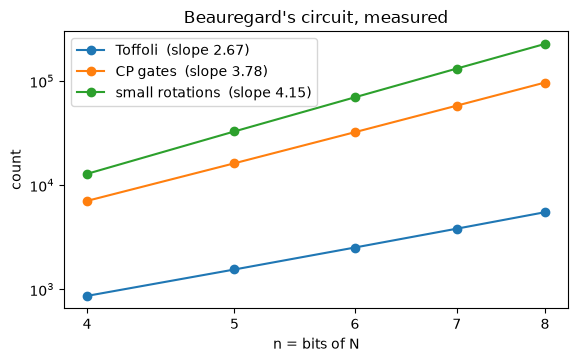

In [16]:
ns = np.array([d[0] for d in data], float)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for k, lab in ((1, "Toffoli"), (2, "CP gates"), (3, "small rotations")):
    ys = np.array([d[k] for d in data], float)
    slope = np.polyfit(np.log(ns), np.log(ys), 1)[0]
    ax.loglog(ns, ys, "o-", label=f"{lab}  (slope {slope:.2f})")
ax.set_xticks(ns, [str(int(v)) for v in ns]); ax.minorticks_off()
ax.set_xlabel("n = bits of N"); ax.set_ylabel("count"); ax.legend(); ax.set_title("Beauregard's circuit, measured")
plt.show()

The slopes approach 3 for Toffolis and 4 for rotations; at small $n$ the lower-order terms still
matter. Extrapolating the **verified** closed forms to RSA-2048, next to the state of the art as
reported by Gidney–Ekerå (2021), which is not computed here:

In [17]:
def beauregard(n, eps_total=1e-3):
    m, t = n + 1, 2 * n
    cp = 4 * n * n * (5 * m * (m - 1) + 2 * m) + t * (t - 1) // 2
    rot = 3 * cp                                  # three P(±θ/2) per CP; nearly all small
    t_rot = 3 * math.log2(rot / eps_total) + 4    # Ross–Selinger, per rotation
    return 4 * n + 2, 8 * n**3 + 22 * n**2, rot, 7 * (8 * n**3 + 22 * n**2) + rot * t_rot

rows = []
for n in (1024, 2048):
    q, tof, rot, T = beauregard(n)
    rows.append([n, "Beauregard, as built here (extrapolated)", f"{q:,}", f"{tof:.2e}", f"{rot:.2e}", f"{T:.1e}"])
    rows.append([n, "Gidney–Ekerå 2021 (reported)", f"{3 * n + 0.002 * n * math.log2(n):,.0f}",
                 f"{0.3 * n**3 + 0.0005 * n**3 * math.log2(n):.2e}", "—", "—"])
table(rows, ["n", "construction", "logical qubits", "Toffoli", "small rotations", "T (with synthesis)"])

| n | construction | logical qubits | Toffoli | small rotations | T (with synthesis) |
|---|---|---|---|---|---|
| 1,024 | Beauregard, as built here (extrapolated) | 4,098 | 8.61e+09 | 6.61e+13 | 1.1e+16 |
| 1,024 | Gidney–Ekerå 2021 (reported) | 3,092 | 3.27e+08 | — | — |
| 2,048 | Beauregard, as built here (extrapolated) | 8,194 | 6.88e+10 | 1.06e+15 | 1.9e+17 |
| 2,048 | Gidney–Ekerå 2021 (reported) | 6,189 | 2.62e+09 | — | — |

Most of that gap is the optimisations in part 4 (Toffoli arithmetic, windowing, coset
representation, oblivious carry runways) together with better error correction. The next part
explains why **rotations** are the thing to eliminate first.

## 3. Fault tolerance: Clifford+T, Solovay–Kitaev, and the price of a phase shift

**The gate set is not free to choose.** An error-correcting code such as the surface code implements
the **Clifford** gates ($H$, $S$, CNOT, Paulis) cheaply, transversally or by lattice surgery with
Pauli-frame tracking. But Clifford circuits alone are classically simulable (Gottesman–Knill), so
they are not universal. Adding **one** non-Clifford gate, $T=P(\pi/4)$, makes the set universal. On
a surface code $T$ cannot be done transversally (Eastin–Knill forbids a transversal universal set).
It is teleported in from a **magic state** made by distillation, which costs orders of magnitude more
space and time than a Clifford. So fault-tolerant cost is counted in **T gates**, or Toffolis, since
a Toffoli is 7 T, or 4 as a temporary AND, or one CCZ magic state.

**Phase shifts.** $P(\pi)=Z$, $P(\pi/2)=S$ and $P(\pi/4)=T$ are in Clifford+T. $P(\pi/2^k)$ for $k\ge3$ is
not, and **cannot be written exactly** over Clifford+T at all: its matrix entries are not in the ring
$\mathbb{Z}[\tfrac1{\sqrt2},i]$ that Clifford+T circuits generate. It has to be *approximated*.

**Solovay–Kitaev theorem.** For any finite gate set generating a dense subgroup of $SU(2)$, closed
under inverses, every single-qubit gate can be approximated to within $\varepsilon$ by a sequence of
length $O(\log^{c}(1/\varepsilon))$. The Dawson–Nielsen construction gives $c\approx3.97$, and later
refinements lower $c$. It is generic and constructive, and it proves that universality is *efficient*:
polylogarithmic in the precision. Its constants are poor, though.

**Ross–Selinger (gridsynth).** For $z$-rotations over Clifford+T, number-theoretic synthesis reaches
$\approx 3\log_2(1/\varepsilon)+O(\log\log(1/\varepsilon))$ T gates, optimal for ancilla-free circuits.
That is the practical cost of one small phase shift: **~60–100 T**.

Both ship with Qiskit. Here they are on $P(\pi/16)$, a phase that appears in every QFT with $n\ge5$:

| method | parameter | T gates | total gates | achieved error | 3·log₂(1/ε) |
|---|---|---|---|---|---|
| Ross–Selinger (gridsynth) | ε = 0.01 | 20 | 49 | 3.7e-03 | 20 |
| Ross–Selinger (gridsynth) | ε = 0.0001 | 42 | 105 | 4.3e-05 | 40 |
| Ross–Selinger (gridsynth) | ε = 1e-06 | 64 | 161 | 4.5e-07 | 60 |
| Ross–Selinger (gridsynth) | ε = 1e-08 | 83 | 205 | 3.8e-09 | 80 |
| Ross–Selinger (gridsynth) | ε = 1e-10 | 104 | 258 | 4.0e-11 | 100 |
| Solovay–Kitaev | recursion 1 | 18 | 34 | 5.9e-02 | — |
| Solovay–Kitaev | recursion 2 | 118 | 210 | 4.1e-02 | — |
| Solovay–Kitaev | recursion 3 | 472 | 856 | 7.0e-03 | — |

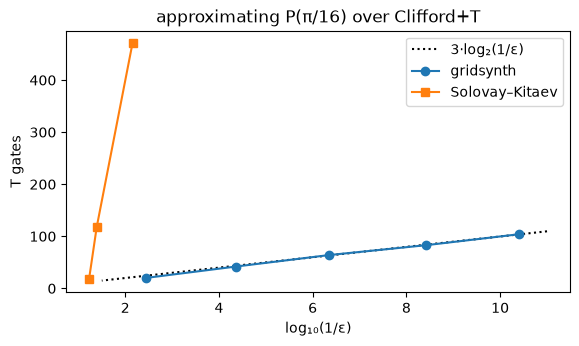

In [18]:
from qiskit.circuit.library import RZGate
from qiskit.synthesis import SolovayKitaevDecomposition, gridsynth_rz

theta = np.pi / 16
target = Operator(RZGate(theta)).data

def dist(qc):                     # operator-norm distance, up to global phase
    U = Operator(qc).data
    ph = np.vdot(U.flatten(), target.flatten())
    return np.linalg.norm(U * np.exp(-1j * np.angle(ph)) - target, 2)

def tcount(qc):
    ops = qc.count_ops()
    return ops.get("t", 0) + ops.get("tdg", 0)

rows, gs, sk = [], [], []
for eps in (1e-2, 1e-4, 1e-6, 1e-8, 1e-10):
    q = gridsynth_rz(theta, epsilon=eps)
    gs.append((dist(q), tcount(q)))
    rows.append(["Ross–Selinger (gridsynth)", f"ε = {eps:g}", tcount(q), q.size(), f"{dist(q):.1e}", round(3 * math.log2(1 / eps))])
skd = SolovayKitaevDecomposition()
for depth in (1, 2, 3):
    q = skd.run(target, recursion_degree=depth)
    sk.append((dist(q), tcount(q)))
    rows.append(["Solovay–Kitaev", f"recursion {depth}", tcount(q), q.size(), f"{dist(q):.1e}", "—"])
table(rows, ["method", "parameter", "T gates", "total gates", "achieved error", "3·log₂(1/ε)"])

fig, ax = plt.subplots(figsize=(6.5, 3.4))
e = np.logspace(-11, -1.5, 50)
ax.plot(np.log10(1 / e), 3 * np.log2(1 / e), "k:", label="3·log₂(1/ε)")
ax.plot([np.log10(1 / d) for d, _ in gs], [T for _, T in gs], "o-", label="gridsynth")
ax.plot([np.log10(1 / d) for d, _ in sk], [T for _, T in sk], "s-", label="Solovay–Kitaev")
ax.set_xlabel("log₁₀(1/ε)"); ax.set_ylabel("T gates"); ax.set_title("approximating P(π/16) over Clifford+T"); ax.legend()
plt.show()

The same on a whole circuit. `SolovayKitaev` is also a transpiler pass. On $\mathrm{QFT}_3$ the CS gates
are already exact in Clifford+T, and the one $\mathrm{CP}(\pi/4)$ contributes three $P(\pm\pi/8)$
that must be approximated. The pass pays for every single-qubit gate and still leaves an error:

In [19]:
from qiskit.quantum_info import process_fidelity
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import SolovayKitaev

q3 = QuantumCircuit(3); q3.append(qft(3), range(3))
r3 = R.count(q3)
print(f"counter: {r3.cphase} CP, {r3.T} T exact (the CS gates), {r3.rotations} small rotations to synthesise")
base = transpile(q3, basis_gates=["cx", "u"], optimization_level=1)
for depth in (1, 2, 3):
    approx = PassManager([SolovayKitaev(recursion_degree=depth)]).run(base)
    print(f"Solovay–Kitaev recursion {depth}: {tcount(approx):5d} T, {approx.size():5d} gates, "
          f"process fidelity {process_fidelity(Operator(approx), Operator(q3)):.6f}")

counter: 3 CP, 6 T exact (the CS gates), 3 small rotations to synthesise
Solovay–Kitaev recursion 1:    96 T,   184 gates, process fidelity 0.991476
Solovay–Kitaev recursion 2:   352 T,   640 gates, process fidelity 0.998585
Solovay–Kitaev recursion 3:  1500 T,  2734 gates, process fidelity 0.999965


**What this means for Shor's circuits:**

* **Fourier arithmetic** (Draper, Beauregard) is built from phase shifts $P(2\pi X2^i/2^m)$ with
  arbitrary angles. In fault-tolerant terms every one is a synthesis problem, and there are $O(n^4)$
  of them (part 2). The total error budget is split across all of them, so each needs
  $\varepsilon/R$ precision and costs $\approx3\log_2(R/\varepsilon)$ T.
* The **approximate QFT** drops $\mathrm{CP}(\pi/2^d)$ for $d>d_{\max}\approx\log_2 n$, reducing the
  rotations per QFT from $O(n^2)$ to $O(n\log n)$ at a total error that stays polynomially small.
* **Toffoli arithmetic** (ripple-carry adders, table lookups) has **no rotations at all**, only
  X, CNOT and Toffoli, so its T-count is exact and it is what every modern resource estimate uses.
  The **temporary AND** then cuts a compute/uncompute Toffoli pair from 14 T to 4.
* The **semiclassical QFT** turns the final QFT's controlled rotations into *classically* controlled
  single-qubit phases. At step $i$ they all act on one qubit, so the controller adds the angles and
  applies **one** rotation per measured bit: $t$ rotations instead of $3t(t-1)/2$.
* A **phase-gradient state** (Kitaev; Gidney) goes further: adding into a register prepared in
  $\sum_k e^{-2\pi ik/2^b}|k\rangle$ applies any rotation by $2\pi x/2^b$ at the Toffoli cost of an
  addition, with no per-angle synthesis. (Not implemented here.)

## 4. Optimisations for factoring, with their measured effect

| # | optimisation | source | module | what it changes |
|---|---|---|---|---|
| 4.1 | control placement: only 2 of 7 blocks carry the outer controls | Beauregard 2003 | `shor_essentials` | fewer multiply-controlled phases |
| 4.2 | approximate QFT | Coppersmith 1994; Barenco et al. 1996 | `qft(n, approx)` | drops $\mathrm{CP}(\pi/2^d)$, $d>d_{\max}$ |
| 4.3 | ripple-carry adder (CDKM) | Cuccaro–Draper–Kutin–Moulton 2004 | `rc_adder` | no rotations: X/CNOT/Toffoli only |
| 4.4 | temporary AND | Gidney 2018 | `qrom`, `ec_gates` | Toffoli pair 14 T → 4 T |
| 4.5 | windowed arithmetic + unary-iteration QROM | Gidney 2019; Babbush et al. 2018 | `windowed`, `qrom` | $n\to\lceil n/w\rceil$ additions per multiplication |
| 4.6 | nested (exponent) windows | Gidney 2019 §3.5 | `nested` | $t\to\lceil t/w_e\rceil$ multiplications |
| 4.7 | measurement-based uncomputation | Gidney 2019 Fig. 3 | `unlookup` | lookup uncompute $O(L)\to O(\sqrt L)$ |
| 4.8 | coset representation | Zalka 2006; Gidney–Ekerå 2021 | `coset` | modular adder → plain adder |
| 4.9 | semiclassical QFT: one counting qubit | Griffiths–Niu 1996; Beauregard 2003 | `semiclassical`, `onectrl` | $4n+2\to2n+3$ qubits |

**Not implemented:** Beauregard's own merging of QFTs across blocks (10 QFTs per modular
adder here, where the register could stay in Fourier space and use 4), oblivious carry runways,
residue-number-system arithmetic (Chevignard–Fouque–Schrottenloher 2025), Gidney's 2025
approximate residue arithmetic, and Regev's algorithm.

### 4.1 Control placement

Controlling every one of the seven blocks gives the obvious $\Lambda(\mathrm{ADD}_N)$. Beauregard's
observation is that blocks (2)–(5) and (7) cancel among themselves when the controls are off, so
only (1) and (6) need them. Each dropped control removes a Toffoli pair around every phase of that
adder:

In [20]:
def c_add_mod_all_controlled(qc, ctrls, X, y, sign, flag, N):
    yw = list(y) + [sign]
    c_add_const(qc, ctrls, X, yw); c_add_const(qc, ctrls, -N, yw)
    qc.mcx(list(ctrls) + [sign], flag); c_add_const(qc, list(ctrls) + [flag], N, yw)
    c_add_const(qc, ctrls, -X, yw); qc.mcx(list(ctrls) + [sign], flag); qc.mcx(ctrls, flag)
    c_add_const(qc, ctrls, X, yw)

rows = []
for N in (15, 63, 255):
    n = math.ceil(math.log2(N))
    for fn, lab in ((c_add_mod_all_controlled, "every block controlled"), (c_add_mod, "2 of 7 (as built)")):
        c, y, sf = QuantumRegister(2), QuantumRegister(n), QuantumRegister(2)
        q = QuantumCircuit(c, y, sf); fn(q, list(c), 7 % N, list(y), sf[0], sf[1], N)
        rows.append(cost(f"N={N}: {lab}", q))
table(rows, ["doubly-controlled modular adder"] + COST)

| doubly-controlled modular adder | qubits | Toffoli | T (Toffoli = 7T) | T (temporary AND) | CP gates | small rotations | T incl. rotations (ε = 10⁻³) |
|---|---|---|---|---|---|---|---|
| N=15: every block controlled | 8 (+2) | 67 | 604 | 284 | 125 | 225 | 13,429 |
| N=15: 2 of 7 (as built) | 8 (+1) | 13 | 220 | 160 | 110 | 204 | 11,848 |
| N=63: every block controlled | 10 (+2) | 91 | 832 | 392 | 245 | 525 | 31,807 |
| N=63: 2 of 7 (as built) | 10 (+1) | 17 | 308 | 228 | 224 | 492 | 29,336 |
| N=255: every block controlled | 12 (+2) | 115 | 1,060 | 500 | 405 | 945 | 57,760 |
| N=255: 2 of 7 (as built) | 12 (+1) | 21 | 396 | 296 | 378 | 900 | 54,396 |

### 4.2 Approximate QFT

`qft(n, approx=d)` keeps $\mathrm{CP}(\pi/2^{k})$ only for $k\le d$. Its distance from the exact QFT is
bounded by the dropped angles, about $n\cdot\pi/2^{d}$:

In [21]:
n = 8
exact = Operator(qft(n)).data
rows = []
for d in (1, 2, 3, 4, 5, 7):
    q = QuantumCircuit(n); q.append(qft(n, approx=d), range(n)); r = R.count(q)
    fid = abs(np.trace(exact.conj().T @ Operator(qft(n, approx=d)).data)) / 2**n
    rows.append([d, r.cphase, r.rotations, f"{fid:.5f}"])
table(rows, [f"d (QFT₈ keeps CP(π/2^k), k ≤ d)", "CP", "small rotations", "|Tr(U†V)|/2ⁿ"])

| d (QFT₈ keeps CP(π/2^k), k ≤ d) | CP | small rotations | \|Tr(U†V)\|/2ⁿ |
|---|---|---|---|
| 1 | 7 | 0 | 0.45855 |
| 2 | 13 | 18 | 0.85252 |
| 3 | 18 | 33 | 0.97090 |
| 4 | 22 | 45 | 0.99514 |
| 5 | 25 | 54 | 0.99934 |
| 7 | 28 | 63 | 1.00000 |

In the full circuit every adder calls `qft(m)`. To build the approximate version, the context manager
below rebinds `qft` for the duration of the build. Then the question is what the approximation
does to the output, not just to the counts:

In [22]:
import shor_essentials as SE

@contextmanager
def approximate_qft(d):
    # Build circuits in which every QFT keeps only CP(pi/2^k), k <= d.
    exact_qft = SE.qft
    SE.qft = lambda n, approx=0: exact_qft(n, approx=d)
    try:
        yield
    finally:
        SE.qft = exact_qft

hit15 = ST.order_success_mask(7, 15, 8)
rows = []
for d in (None, 4, 3, 2):
    if d is None:
        qa = SE.order_circuit(7, 15)
    else:
        with approximate_qft(d):
            qa = SE.order_circuit(7, 15)
    ca = sample(qa, 4096); ea = ST.empirical(ST.order_counts(ca), 256); ra = R.count(qa)
    rows.append(["exact" if d is None else f"d = {d}", ra.cphase, ra.rotations,
                 f"{ST.tvd(ea, theory):.3f}", f"{ea[hit15].sum():.3f}", order_from_counts(ca, 7, 15, 8)])
table(rows, ["every QFT in the N = 15 circuit", "CP", "small rotations",
             f"TVD from exact (noise bound {ST.tvd_null(theory, 4096):.3f})", "P(one shot gives r = 4)", "recovered r"])

rows = [cost("exact QFT", SE.order_circuit(2, 129))]
with approximate_qft(4):
    rows.append(cost("approximate, d = 4", SE.order_circuit(2, 129)))
table(rows, ["N = 129 (n = 8)"] + COST)

| every QFT in the N = 15 circuit | CP | small rotations | TVD from exact (noise bound 0.032) | P(one shot gives r = 4) | recovered r |
|---|---|---|---|---|---|
| exact | 7,068 | 12,855 | 0.006 | 0.501 | 4 |
| d = 4 | 7,062 | 12,837 | 0.006 | 0.501 | 4 |
| d = 3 | 6,418 | 10,905 | 0.138 | 0.451 | 4 |
| d = 2 | 5,133 | 7,050 | 0.594 | 0.245 | 4 |

| N = 129 (n = 8) | qubits | Toffoli | T (Toffoli = 7T) | T (temporary AND) | CP gates | small rotations | T incl. rotations (ε = 10⁻³) |
|---|---|---|---|---|---|---|---|
| exact QFT | 34 (+1) | 5,504 | 102,273 | 76,673 | 96,888 | 227,704 | 19,684,817 |
| approximate, d = 4 | 34 (+1) | 5,504 | 102,273 | 76,673 | 71,222 | 150,706 | 13,062,989 |

Two lessons. The circuit holds $64\times5=320$ Fourier additions, and each one's QFT pair now carries
its own approximation error. The errors **accumulate**: the histogram drifts away from the exact
distribution as $d$ drops, and the probability that a shot yields $r$ falls with it. The accounting is
the same as for synthesis: one error budget is shared by every approximation, so $d$ has to grow like
$\log_2(\#\text{additions}/\varepsilon)$. The saving is asymptotic: at $n=8$, $d=4$ already removes about
a third of the rotations.

### 4.3 Ripple-carry (CDKM) arithmetic: no rotations at all

Cuccaro et al. add with a ladder of **MAJ** (majority) and **UMA** (unmajority-and-add) blocks, each one
Toffoli and two CNOTs:

$$\mathrm{ADD}=\mathrm{UMA}_0\cdots\mathrm{UMA}_{m-1}\;\mathrm{MAJ}_{m-1}\cdots\mathrm{MAJ}_0,\qquad 2m\ \text{Toffolis},\ \text{one carry ancilla}.$$

The seven-block modular adder stays as it is; only the adder inside changes.

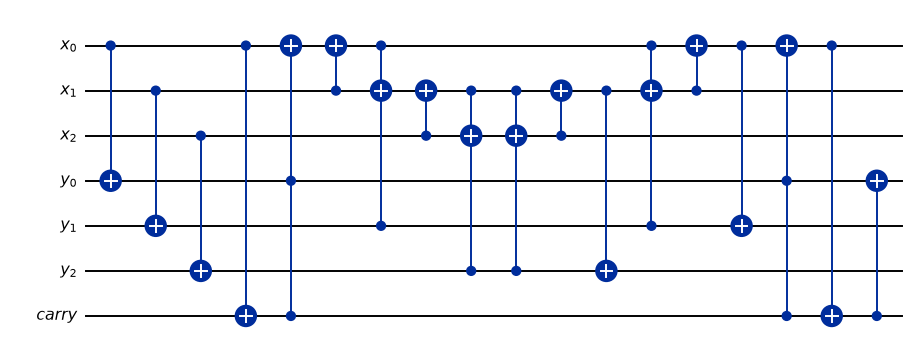

| one rung Λ(U_a) | qubits | Toffoli | T (Toffoli = 7T) | T (temporary AND) | CP gates | small rotations | T incl. rotations (ε = 10⁻³) |
|---|---|---|---|---|---|---|---|
| n=4: Fourier (Beauregard) | 11 (+1) | 108 | 1,786 | 1,306 | 880 | 1,599 | 97,726 |
| n=4: ripple-carry (CDKM) | 17 (+1) | 748 | 5,236 | 4,356 | 0 | 0 | 5,236 |
| n=6: Fourier (Beauregard) | 15 (+1) | 210 | 3,734 | 2,774 | 2,688 | 5,788 | 420,470 |
| n=6: ripple-carry (CDKM) | 23 (+1) | 1,554 | 10,878 | 9,078 | 0 | 0 | 10,878 |
| n=8: Fourier (Beauregard) | 19 (+1) | 344 | 6,388 | 4,788 | 6,048 | 14,199 | 1,071,313 |
| n=8: ripple-carry (CDKM) | 29 (+1) | 2,648 | 18,536 | 15,496 | 0 | 0 | 18,536 |
| n=10: Fourier (Beauregard) | 23 (+1) | 510 | 9,746 | 7,346 | 11,440 | 28,254 | 2,270,066 |
| n=10: ripple-carry (CDKM) | 35 (+1) | 4,030 | 28,210 | 23,610 | 0 | 0 | 28,210 |

In [23]:
from rc_adder import rc_add, rc_c_ua, rc_c_add_mod
x3, y3, cr = QuantumRegister(3, "x"), QuantumRegister(3, "y"), QuantumRegister(1, "carry")
q = QuantumCircuit(x3, y3, cr)
rc_add(q, list(x3), list(y3), cr[0])
display(q.draw("mpl", scale=0.7, fold=-1))

rows = []
for n, N in ((4, 15), (6, 33), (8, 129), (10, 513)):
    for kind in ("Fourier (Beauregard)", "ripple-carry (CDKM)"):
        c, x, yq, sf, a = QuantumRegister(1), QuantumRegister(n), QuantumRegister(n), QuantumRegister(2), QuantumRegister(n + 2)
        if kind.startswith("Fourier"):
            q = QuantumCircuit(c, x, yq, sf); c_ua(q, c[0], 2, list(x), list(yq), sf[0], sf[1], N)
        else:
            q = QuantumCircuit(c, x, yq, sf, a); rc_c_ua(q, c[0], 2, list(x), list(yq), sf[0], sf[1], N, list(a))
        rows.append(cost(f"n={n}: {kind}", q))
table(rows, ["one rung Λ(U_a)"] + COST)

The ripple-carry rung has **7–8× more Toffolis** at these sizes ($36n^2+43n$ against $4n^2+11n$, so 9×
asymptotically) and **zero rotations**. Once each rotation is priced at its synthesis cost it is about
**20× cheaper in T at $n=4$ and 80× at $n=10$**, and the gap keeps growing, since rotations scale as
$n^4$ and Toffolis as $n^3$. That is the trade every modern construction makes. It costs $n+2$ more qubits
($5n+4$ in total). Checked on every input:

In [24]:
n, N = 4, 15
c, x, yq, sf, a = QuantumRegister(1), QuantumRegister(n), QuantumRegister(n), QuantumRegister(2), QuantumRegister(n + 2)
ok = True
for x0 in range(1, N):
    q = QuantumCircuit(c, x, yq, sf, a); q.x(c[0])
    for i in range(n):
        if (x0 >> i) & 1: q.x(x[i])
    rc_c_ua(q, c[0], 7, list(x), list(yq), sf[0], sf[1], N, list(a))
    v = basis_out(q)
    ok &= (v >> 1) & 15 == 7 * x0 % N and v >> 5 == 0
print("rc_c_ua: |x>|0> -> |7x mod 15>|0>, all scratch clean, every x:", ok)

rc_c_ua: |x>|0> -> |7x mod 15>|0>, all scratch clean, every x: True


### 4.4 The temporary AND: 4 T to compute, 0 to uncompute

When a Toffoli's target starts in $|0\rangle$, Gidney's AND computes $a\wedge b$ with 4 T gates
(T-depth 1). The uncompute is an $X$-basis measurement followed by a classically controlled CZ,
Clifford only, **0 T**:

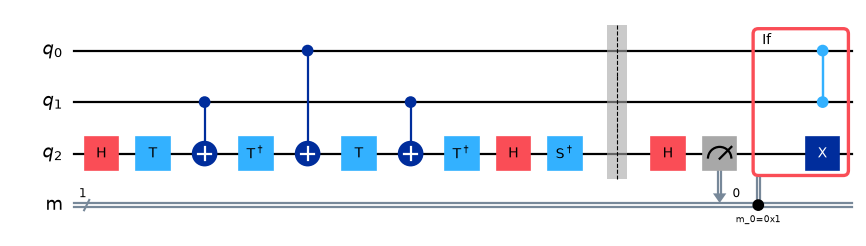

| circuit | compute/uncompute pairs | T | T per pair | measurements |
|---|---|---|---|---|
| L = 4-entry lookup, Toffoli | 3 | 42 | 14 | 0 |
| L = 4-entry lookup, temporary AND | 3 | 12 | 4 | 3 |
| L = 16-entry lookup, Toffoli | 15 | 210 | 14 | 0 |
| L = 16-entry lookup, temporary AND | 15 | 60 | 4 | 15 |
| L = 64-entry lookup, Toffoli | 63 | 882 | 14 | 0 |
| L = 64-entry lookup, temporary AND | 63 | 252 | 4 | 63 |

In [25]:
from qrom import and_compute, and_uncompute, lookup_ui, lookup_ui_ta
a3 = QuantumRegister(3, "q"); cb = ClassicalRegister(1, "m")
g = QuantumCircuit(a3, cb)
and_compute(g, a3[0], a3[1], a3[2]); g.barrier(); and_uncompute(g, a3[0], a3[1], a3[2], cb[0])
display(g.draw("mpl", scale=0.8))

rows = []
for w in (2, 4, 6):
    for fn, lab in ((lookup_ui, "Toffoli"), (lookup_ui_ta, "temporary AND")):
        ctl, ad, out, anc = QuantumRegister(1), QuantumRegister(w), QuantumRegister(4), QuantumRegister(w)
        q = QuantumCircuit(ctl, ad, out, anc, ClassicalRegister(1))
        table_ = [(7 * j) % 16 for j in range(2**w)]
        if fn is lookup_ui:
            fn(q, ctl[0], list(ad), list(out), table_, list(anc))
        else:
            fn(q, ctl[0], list(ad), list(out), table_, list(anc), q.clbits[0])
        r = R.count(q)
        pairs = 2**w - 1                                   # one AND pair per tree node
        rows.append([f"L = {2**w}-entry lookup, {lab}", pairs, r.T, r.T // pairs, r.measure])
table(rows, ["circuit", "compute/uncompute pairs", "T", "T per pair", "measurements"])

That is the 3.5× (14 T → 4 T per pair). In the tables above, the *T (temporary AND)* column prices
every compute/uncompute ladder this way.

### 4.5 Windowed arithmetic

Instead of one doubly-controlled modular addition per bit of $x$, take $w$ bits at a time and **look up**
the window's contribution $a\cdot j\cdot2^i \bmod N$ from a classical table. Then do one addition of a
*quantum* register per window:

$$\mathrm{CMULT}(a)=\prod_{\text{windows }i}\Big(\mathrm{LOOKUP}_i^{\dagger}\cdot\mathrm{ADD}_N(\text{tmp})\cdot\mathrm{LOOKUP}_i\Big),\qquad \lceil n/w\rceil\ \text{additions instead of } n.$$

The lookup is Babbush et al.'s **unary iteration**, a binary tree of Toffolis walking the
address. It uses $2(L-1)$ Toffolis for $L=2^w$ entries and $w$ ancillas, and each leaf's data is
loaded with CNOTs:

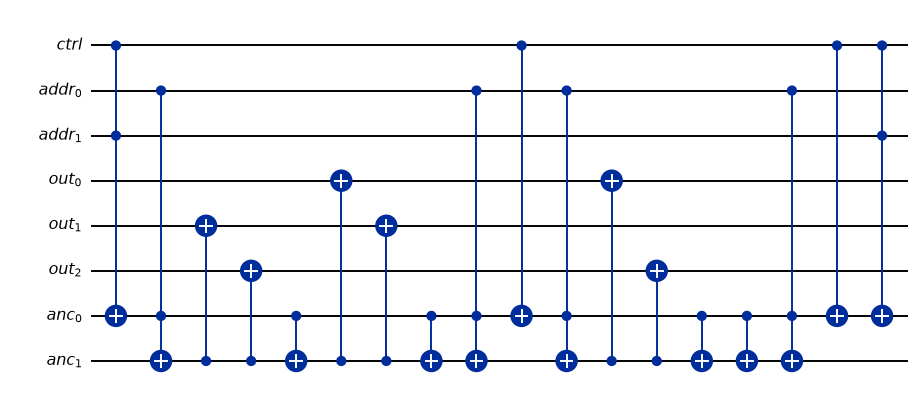

In [26]:
ctl, ad, out, anc = QuantumRegister(1, "ctrl"), QuantumRegister(2, "addr"), QuantumRegister(3, "out"), QuantumRegister(2, "anc")
q = QuantumCircuit(ctl, ad, out, anc)
lookup_ui(q, ctl[0], list(ad), list(out), [0, 5, 3, 6], list(anc))
display(q.draw("mpl", scale=0.7, fold=-1))

In [27]:
from windowed import windowed_c_ua, windowed_order_circuit
rows = []
for n, N in ((4, 15), (8, 129), (12, 2049)):
    c, x, yq, sf = QuantumRegister(1), QuantumRegister(n), QuantumRegister(n), QuantumRegister(2)
    q = QuantumCircuit(c, x, yq, sf); c_ua(q, c[0], 2, list(x), list(yq), sf[0], sf[1], N)
    rows.append(cost(f"n={n}: shift-and-add, {2 * n} modular additions", q))
    for w in (2, 4):
        tmp, un = QuantumRegister(n), QuantumRegister(w)
        q = QuantumCircuit(c, x, yq, sf, tmp, un)
        windowed_c_ua(q, c[0], 2, list(x), list(yq), sf[0], sf[1], N, list(tmp), list(un), w)
        rows.append(cost(f"n={n}: windowed w={w}, {2 * math.ceil(n / w)} additions", q))
table(rows, ["one rung Λ(U_a)"] + COST)

| one rung Λ(U_a) | qubits | Toffoli | T (Toffoli = 7T) | T (temporary AND) | CP gates | small rotations | T incl. rotations (ε = 10⁻³) |
|---|---|---|---|---|---|---|---|
| n=4: shift-and-add, 8 modular additions | 11 (+1) | 108 | 1,786 | 1,306 | 880 | 1,599 | 97,726 |
| n=4: windowed w=2, 4 additions | 17 | 52 | 1,004 | 1,004 | 588 | 980 | 59,804 |
| n=4: windowed w=4, 2 additions | 19 | 124 | 1,188 | 1,188 | 294 | 490 | 30,098 |
| n=8: shift-and-add, 16 modular additions | 19 (+1) | 344 | 6,388 | 4,788 | 6,048 | 14,199 | 1,071,313 |
| n=8: windowed w=2, 8 additions | 29 | 104 | 3,256 | 3,256 | 4,008 | 8,952 | 665,704 |
| n=8: windowed w=4, 4 additions | 31 | 248 | 3,000 | 3,000 | 2,004 | 4,476 | 316,320 |
| n=12: shift-and-add, 24 modular additions | 27 (+1) | 708 | 13,808 | 10,448 | 19,344 | 49,393 | 3,965,248 |
| n=12: windowed w=2, 12 additions | 41 | 156 | 6,756 | 6,756 | 12,756 | 31,404 | 2,519,076 |
| n=12: windowed w=4, 6 additions | 43 | 372 | 5,436 | 5,436 | 6,378 | 15,702 | 1,183,086 |

End to end on Aer: $N=15$ with $w=2$. Here $t=4$ is legitimate because $r=4$ divides $2^4$; it keeps
the statevector to 20 qubits.

20 qubits, 2.5s; TVD from exact 0.003 (bound 0.047); r = 4


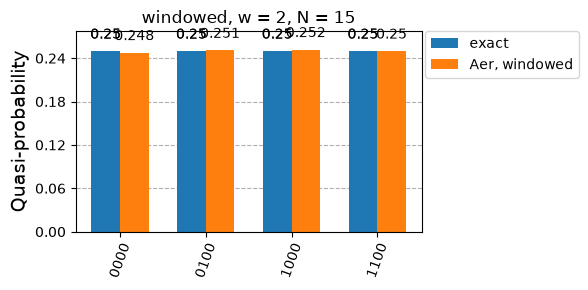

In [28]:
qw = windowed_order_circuit(7, 15, w=2, t=4)
t0 = time.time(); cw = sample(qw, 2048); dt = time.time() - t0
th4 = ST.order_finding_probs(7, 15, 4)
ew = ST.empirical(ST.order_counts(cw), 16)
print(f"{qw.num_qubits} qubits, {dt:.1f}s; TVD from exact {ST.tvd(ew, th4):.3f} (bound {ST.tvd_null(th4, 2048):.3f}); "
      f"r = {order_from_counts(cw, 7, 15, 4)}")
plot_distribution([{format(y, "04b"): p for y, p in enumerate(th4) if p > 1e-9}, cw],
                  legend=["exact", "Aer, windowed"], title="windowed, w = 2, N = 15", figsize=(6, 3))

### 4.6 Nested windows over the exponent

Windowing the **exponent** too: take $w_e$ counting qubits at a time and let the lookup address be
(exponent window, multiplicand window). One multiplication then handles $w_e$ rungs, so there are
$\lceil t/w_e\rceil$ multiplications instead of $t$. They need no control (exponent window $=0$ multiplies
by 1), and the swap becomes a free relabelling:

In [29]:
from nested import nested_order_circuit
rows = [cost("plain, t = 8 multiplications", order_circuit(7, 15)),
        cost("windowed w=2", windowed_order_circuit(7, 15, w=2)),
        cost("nested w_e=2, w_m=2: 4 multiplications", nested_order_circuit(7, 15, 2, 2))]
table(rows, ["order finding, N = 15"] + COST)

qn = nested_order_circuit(7, 15, 2, 2, t=4)
t0 = time.time(); cn = sample(qn, 1024); dt = time.time() - t0
en = ST.empirical(ST.order_counts(cn), 16)
print(f"nested, t = 4, on Aer: {qn.num_qubits} qubits, {dt:.1f}s; TVD from exact {ST.tvd(en, th4):.3f} "
      f"(bound {ST.tvd_null(th4, 1024):.3f}); r = {order_from_counts(cn, 7, 15, 4)}")

| order finding, N = 15 | qubits | Toffoli | T (Toffoli = 7T) | T (temporary AND) | CP gates | small rotations | T incl. rotations (ε = 10⁻³) |
|---|---|---|---|---|---|---|---|
| plain, t = 8 multiplications | 18 (+1) | 864 | 14,309 | 10,469 | 7,068 | 12,855 | 978,434 |
| windowed w=2 | 24 | 416 | 8,053 | 8,053 | 4,732 | 7,903 | 592,875 |
| nested w_e=2, w_m=2: 4 multiplications | 27 | 960 | 9,301 | 9,301 | 2,380 | 3,983 | 280,145 |

nested, t = 4, on Aer: 23 qubits, 13.6s; TVD from exact 0.014 (bound 0.064); r = 4


### 4.7 Measurement-based uncomputation

A lookup is normally uncomputed by running it again ($2(L-1)$ Toffolis). Instead, measure its output
in the $X$ basis. That leaves a phase $(-1)^{m\cdot T[a]}$ on the address, which a **phase fixup**
removes with $O(\sqrt L)$ Toffolis. The fixup depends on the measured $m$, so this is a hybrid
circuit → measure → classical → circuit loop (`run_windowed_acc_mbu`):

In [30]:
from unlookup import run_windowed_acc_mbu, uncompute_cost
table([[2**w, *uncompute_cost(2**w, 8), f"{uncompute_cost(2**w, 8)[0] / uncompute_cost(2**w, 8)[1]:.1f}×"]
       for w in (2, 4, 6, 8, 10)], ["L entries", "re-run lookup (Toffoli)", "measure + fixup (Toffoli)", "saving"])
x_out, y_out, scratch, nmeas = run_windowed_acc_mbu(SIM, 15, 7, 5, 1, 2, 4)
print(f"y += 7·5 mod 15 with every lookup uncomputed by measurement: x = {x_out}, y = {y_out}, "
      f"scratch = {scratch}, {nmeas} X-basis measurements")

| L entries | re-run lookup (Toffoli) | measure + fixup (Toffoli) | saving |
|---|---|---|---|
| 4 | 6 | 3 | 2.0× |
| 16 | 30 | 9 | 3.3× |
| 64 | 126 | 21 | 6.0× |
| 256 | 510 | 45 | 11.3× |
| 1,024 | 2,046 | 93 | 22.0× |

y += 7·5 mod 15 with every lookup uncomputed by measurement: x = 5, y = 5, scratch = 0, 2 X-basis measurements


### 4.8 Coset representation: the modular adder becomes a plain adder

Store $k$ as the periodic superposition $|k\rangle_{\text{coset}}=2^{-c/2}\sum_{j<2^c}|jN+k\rangle$ on $n+c$
qubits. Every branch is $\equiv k \pmod N$, so a **plain** addition of $X$ is already modular addition.
When the sum overflows, the comb just re-indexes. Only the top branch can wrap past $2^{n+c}$,
so the error is $\approx2^{-c}$ per addition. Blocks (2)–(7), the sign and the flag all disappear:

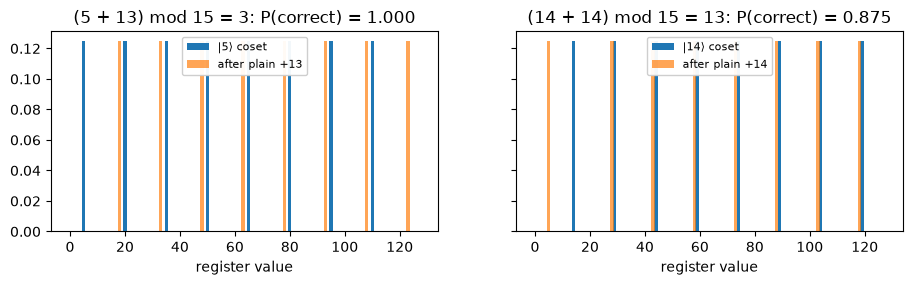

| multiply-accumulate | qubits | Toffoli | T (Toffoli = 7T) | T (temporary AND) | CP gates | small rotations | T incl. rotations (ε = 10⁻³) |
|---|---|---|---|---|---|---|---|
| n=4: Beauregard CMULT | 11 (+1) | 52 | 878 | 638 | 440 | 788 | 48,158 |
| n=4: coset CMULT, c = 3 | 15 (+1) | 98 | 959 | 469 | 343 | 699 | 42,899 |
| n=4: coset CMULT, c = 16 | 41 (+1) | 800 | 7,940 | 3,940 | 8,000 | 21,510 | 1,621,190 |
| n=8: Beauregard CMULT | 19 (+1) | 168 | 3,166 | 2,366 | 3,024 | 7,062 | 518,692 |
| n=8: coset CMULT, c = 3 | 23 (+1) | 242 | 2,387 | 1,177 | 1,331 | 3,183 | 218,831 |
| n=8: coset CMULT, c = 19 | 55 (+1) | 1,458 | 14,499 | 7,209 | 19,683 | 54,507 | 4,484,073 |

In [31]:
import coset as CS
N, cpad = 15, 3
mw = CS.coset_width(N, cpad)
reg = QuantumRegister(mw, "k")
fig, axes = plt.subplots(1, 2, figsize=(11, 2.6), sharey=True)
for ax, (k, X) in zip(axes, ((5, 13), (14, 14))):
    q = QuantumCircuit(reg); CS.encode(q, reg, k, N, cpad); q.save_probabilities(label="before")
    CS.add(q, X, reg, N); q.save_probabilities(label="after")
    res = SIM.run(transpile(q, SIM, optimization_level=0)).result().data(0)
    b, a = np.asarray(res["before"]), np.asarray(res["after"])
    ok = sum(a[v] for v in range(2**mw) if v % N == (k + X) % N)
    ax.bar(np.arange(2**mw), b, width=1.2, label=f"|{k}⟩ coset")
    ax.bar(np.arange(2**mw), a, width=1.2, alpha=0.7, label=f"after plain +{X}")
    ax.set_title(f"({k} + {X}) mod 15 = {(k + X) % N}: P(correct) = {ok:.3f}"); ax.set_xlabel("register value")
    ax.legend(fontsize=8, loc="upper center", framealpha=0.95)
plt.show()

rows = []
for n, N in ((4, 15), (8, 129)):
    c, x, yq, sf = QuantumRegister(1), QuantumRegister(n), QuantumRegister(n), QuantumRegister(2)
    q = QuantumCircuit(c, x, yq, sf); SE.c_mult_acc(q, c[0], 2, list(x), list(yq), sf[0], sf[1], N)
    rows.append(cost(f"n={n}: Beauregard CMULT", q))
    for cp_ in (3, CS.padding_for(n, n)):             # toy padding; Gidney–Ekerå's
        xc, yc = QuantumRegister(n + cp_), QuantumRegister(n + cp_)
        q = QuantumCircuit(c, xc, yc); CS.c_mult_acc(q, c[0], 2, list(xc), list(yc), N)
        rows.append(cost(f"n={n}: coset CMULT, c = {cp_}", q))
table(rows, ["multiply-accumulate"] + COST)

With $k=14$, $X=14$ the top branch $7\cdot15+14=119$ plus 14 passes $2^7=128$ and wraps, and exactly
one of the $2^c=8$ branches is lost: $P(\text{correct})=7/8$. With the padding Gidney–Ekerå use,
$c\approx2\log_2n+\log_2(\#\text{additions})+10$, that error is negligible. Coset arithmetic removes
the comparison and the flag, but pays for wider registers. With toy padding ($c=3$) it already saves
T at $n=8$. With the padding the error analysis demands ($c=16$–$19$ here) the wide registers swamp the
saving at toy sizes. The win is asymptotic, because $c$ grows only like $\log n$. (`coset.py` supplies the adder and
multiplier; the full coset order-finding circuit is not built.)

### 4.9 The semiclassical QFT: one counting qubit

Every rotation in $\mathrm{QFT}^{\dagger}_t$ is controlled by a qubit that is **about to be measured**. By the
deferred-measurement principle, measuring first and controlling classically gives the same
distribution. So the counting register never has to exist: one qubit is Hadamarded, drives
rung $t-1-i$, gets the phase $P\big(-\pi\sum_{j<i}m_j/2^{\,i-j}\big)$ from the bits already measured,
is Hadamarded, measured, and reset:

$$\text{step } i:\quad \mathrm{reset}\cdot\mathrm{measure}\cdot H\cdot\prod_{j<i}P\big(-\pi/2^{\,i-j}\big)^{m_j}\cdot\Lambda\big(U_a^{2^{\,t-1-i}}\big)\cdot H .$$

The loop is `semiclassical.semiclassical_iqft(qc, ctrl, out, rungs)`, shared by factoring and ECDLP. Here
it is with three boxed rungs (`if_else` blocks are the classically controlled phases):

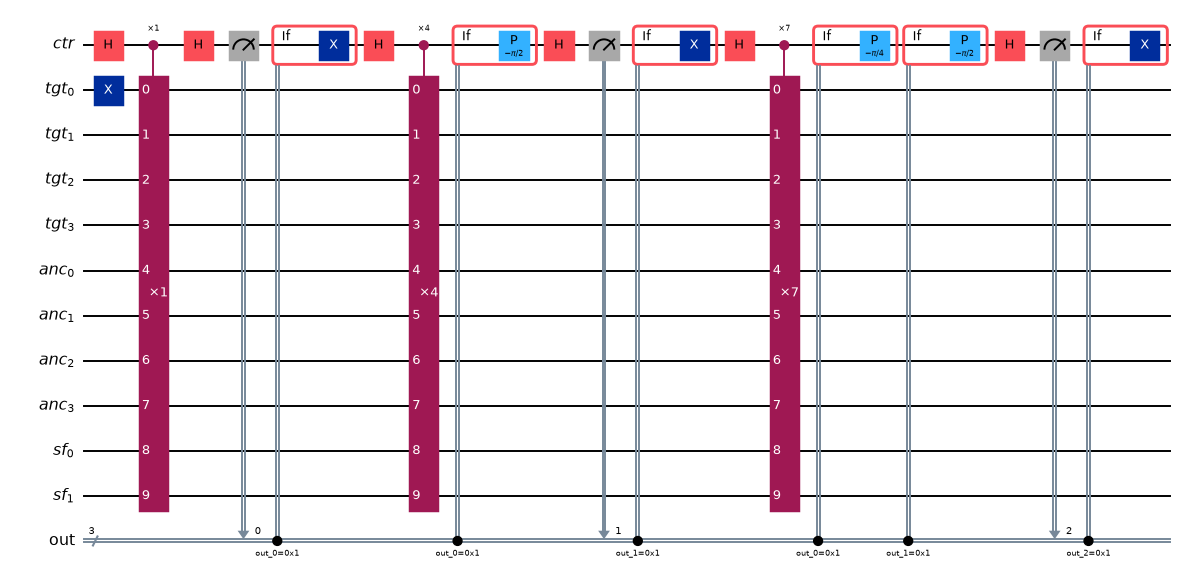

In [32]:
from semiclassical import semiclassical_iqft
from onectrl import order_circuit_1c
N, A, n, t = 15, 7, 4, 3
ctr, tgt, anc, sf = QuantumRegister(1, "ctr"), QuantumRegister(n, "tgt"), QuantumRegister(n, "anc"), QuantumRegister(2, "sf")
out = ClassicalRegister(t, "out")
demo = QuantumCircuit(ctr, tgt, anc, sf, out); demo.x(tgt[0])

def boxed_rung(k):
    a = pow(A, 2**k, N)
    g = cbox(f"×{a}", 1, 2 * n + 2, lambda q, b: c_ua(q, b[0], a, b[1:1 + n], b[1 + n:1 + 2 * n], b[-2], b[-1], N))
    return lambda qc, c: qc.append(g, [c, *tgt, *anc, *sf])

semiclassical_iqft(demo, ctr[0], out, [boxed_rung(k) for k in range(t)])
demo.draw("mpl", scale=0.7, fold=-1)

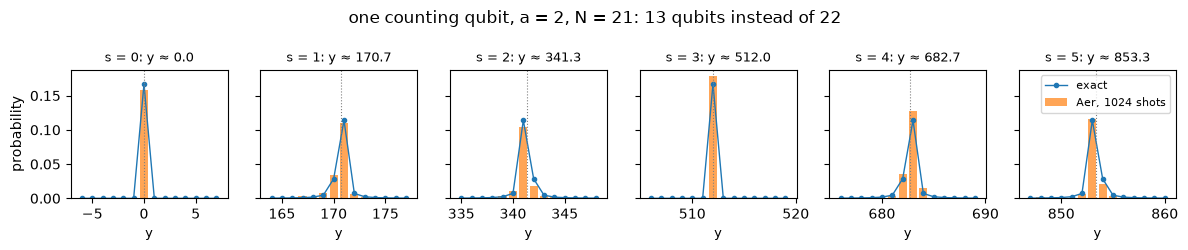

| N | a | r | qubits | full circuit | TVD / noise bound | P(one shot gives r): exact / measured | recovered r | Aer time |
|---|---|---|---|---|---|---|---|---|
| 15 | 7 | 4 | 11 | 18 | 0.021 / 0.044 | 0.500 / 0.479 | 4 | 8s |
| 21 | 2 | 6 | 13 | 22 | 0.075 / 0.108 | 0.322 / 0.313 | 6 | 31s |

In [33]:
rows = []
for N, A, shots in ((15, 7, 2048), (21, 2, 1024)):
    n = math.ceil(math.log2(N)); t = 2 * n
    q1 = order_circuit_1c(A, N)
    t0 = time.time(); c1 = sample(q1, shots); dt = time.time() - t0
    th = ST.order_finding_probs(A, N, t); e1 = ST.empirical(ST.order_counts(c1), 2**t)
    rr = ST.multiplicative_order(A, N); hit = ST.order_success_mask(A, N, t)
    rows.append([N, A, rr, q1.num_qubits, 4 * n + 2, f"{ST.tvd(e1, th):.3f} / {ST.tvd_null(th, shots):.3f}",
                 f"{th[hit].sum():.3f} / {e1[hit].sum():.3f}", order_from_counts(c1, A, N, t), f"{dt:.0f}s"])
    if N == 21:
        plot_order(th, t, rr, ST.order_counts(c1), title=f"one counting qubit, a = 2, N = 21: {q1.num_qubits} qubits instead of {4 * n + 2}")
table(rows, ["N", "a", "r", "qubits", "full circuit", "TVD / noise bound", "P(one shot gives r): exact / measured", "recovered r", "Aer time"])

Mid-circuit measurement makes Aer simulate **shot by shot**, so the one-control circuit is slower
to *simulate* even though it is smaller. On hardware it is simply smaller. `tests/test_semiclassical.py`
checks it exactly: by enumerating measurement branches, its distribution equals the full circuit's
to $10^{-13}$.

### 4.10 Putting them together

Because the semiclassical driver takes the rungs as callbacks, the optimisations compose. Here is the
whole ladder for $N=15$ in every variant, including **one counting qubit + ripple-carry**, which
has no quantum-controlled rotations at all:

| N = 15, t = 8 | qubits | Toffoli | T (Toffoli = 7T) | T (temporary AND) | CP gates | small rotations | T incl. rotations (ε = 10⁻³) |
|---|---|---|---|---|---|---|---|
| Beauregard (baseline) | 18 (+1) | 864 | 14,309 | 10,469 | 7,068 | 12,855 | 978,434 |
| windowed, w = 2 | 24 | 416 | 8,053 | 8,053 | 4,732 | 7,903 | 592,875 |
| nested windows, 2 × 2 | 27 | 960 | 9,301 | 9,301 | 2,380 | 3,983 | 280,145 |
| ripple-carry | 24 (+1) | 5,984 | 41,909 | 34,869 | 28 | 63 | 44,996 |
| one counting qubit | 11 (+1) | 864 | 14,294 | 10,454 | 7,040 | 12,807 | 974,819 |
| one counting qubit + ripple-carry | 17 (+1) | 5,984 | 41,894 | 34,854 | 0 | 15 | 42,584 |

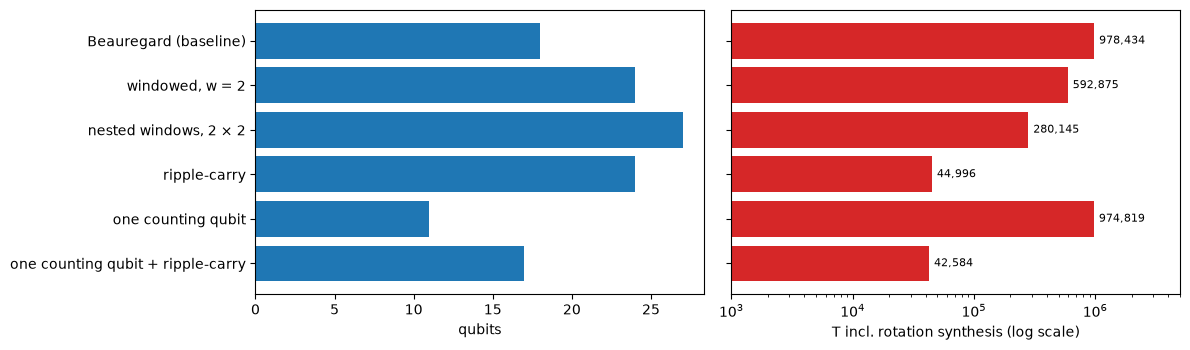

In [34]:
def rc_order_circuit(A, N, one_control=False):
    n = math.ceil(math.log2(N)); t = 2 * n
    ctr = QuantumRegister(1 if one_control else t, "ctr")
    tgt, anc, sf, rca = QuantumRegister(n, "tgt"), QuantumRegister(n, "anc"), QuantumRegister(2, "sf"), QuantumRegister(n + 2, "rc")
    out = ClassicalRegister(t, "out")
    qc = QuantumCircuit(ctr, tgt, anc, sf, rca, out); qc.x(tgt[0])
    rung = lambda k: (lambda q, c: rc_c_ua(q, c, pow(A, 2**k, N), list(tgt), list(anc), sf[0], sf[1], N, list(rca)))
    if one_control:
        semiclassical_iqft(qc, ctr[0], out, [rung(k) for k in range(t)])
    else:
        qc.h(ctr)
        for k in range(t):
            rung(k)(qc, ctr[k])
        qc.append(qft(t).inverse(), ctr); qc.measure(ctr, out)
    return qc

variants = [("Beauregard (baseline)", order_circuit(7, 15)),
            ("windowed, w = 2", windowed_order_circuit(7, 15, w=2)),
            ("nested windows, 2 × 2", nested_order_circuit(7, 15, 2, 2)),
            ("ripple-carry", rc_order_circuit(7, 15)),
            ("one counting qubit", order_circuit_1c(7, 15)),
            ("one counting qubit + ripple-carry", rc_order_circuit(7, 15, one_control=True))]
rows = [cost(lab, q) for lab, q in variants]
table(rows, ["N = 15, t = 8"] + COST)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
labs = [r_[0] for r_ in rows]
a1.barh(labs, [int(str(r_[1]).split()[0]) for r_ in rows]); a1.set_xlabel("qubits"); a1.invert_yaxis()
tv = [r_[7] for r_ in rows]
a2.barh(labs, tv, color="tab:red"); a2.set_xscale("log"); a2.set_xlim(1e3, 5e6)
a2.set_xlabel("T incl. rotation synthesis (log scale)"); a2.invert_yaxis(); a2.set_yticklabels([])
for i_, v_ in enumerate(tv):
    a2.text(v_ * 1.1, i_, f"{v_:,}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

Two views of the same circuits. In raw Toffolis the ripple-carry variants look 7× *worse*, and in qubits
the windowed ones look worse too. But price each small rotation at its synthesis cost and the
rotation-free variants win by **more than an order of magnitude already at $N=15$**, and the gap widens
with $n$ (§4.3). One counting qubit plus ripple-carry uses fewer qubits than the baseline and has no
quantum-controlled rotations left: only the 15 small classically controlled phases of the semiclassical
QFT, which could be merged into one per measured bit. (The approximate QFT is left out here. At
$N=15$ it only pays with a lossy $d$, see §4.2.)

## 5. The minimal circuit for the elliptic-curve discrete logarithm

Given a point $P$ of order $r$ on $E(\mathbb{F}_p)$ and $Q=[k]P$, find $k$. The group is now the curve,
and "multiply by $a$" becomes **add a point**. For a fixed point $R$,

$$A_R\,|X\rangle=|X+R\rangle$$

is a permutation of the points, hence a unitary. Shor's circuit uses two registers of $m$ qubits
and an accumulator started at a fixed offset $S$ (affine formulas cannot represent the point at infinity):

$$\frac{1}{2^m}\sum_{u,v}|u\rangle|v\rangle|S\rangle\ \xrightarrow{\ \prod_i\Lambda_{u_i}(A_{[2^i]P})\,\prod_i\Lambda_{v_i}(A_{[2^i]Q})\ }\ \frac{1}{2^m}\sum_{u,v}|u\rangle|v\rangle\,|S+[u+kv]P\rangle$$

then $\mathrm{QFT}^{\dagger}\otimes\mathrm{QFT}^{\dagger}$ and measure $(j_1,j_2)$. The accumulator depends on $(u,v)$ only through
$u+kv \bmod r$, so the QFT concentrates on pairs with $j_2\,r/2^m\equiv k\,(j_1r/2^m) \pmod r$. Rounding gives
$a_i=\mathrm{round}(j_ir/2^m)$ and $k=a_2a_1^{-1} \bmod r$ (Ekerå's post-processing).

In [35]:
import ec_classical as C
import ec_shor as S
curve, G = C.CLASSIQ, C.CLASSIQ_G
r = curve.point_order(G)
Q = C.CLASSIQ_Q
k_true = next(k for k in range(r) if curve.mul(k, G) == Q)
pts = [P for P in curve.points() if not P.inf]
print(f"curve y² = x³ + {curve.a}x + {curve.b} over F_{curve.p}: {len(pts)} affine points + O")
print(f"G = ({G.x}, {G.y}) has order r = {r};  Q = ({Q.x}, {Q.y}) = [{k_true}]G")
table([[i, "O" if (P := curve.mul(i, G)).inf else f"({P.x}, {P.y})"] for i in range(r)], ["i", "[i]G"])

curve y² = x³ + 5x + 4 over F_7: 9 affine points + O
G = (0, 5) has order r = 5;  Q = (0, 2) = [4]G


| i | [i]G |
|---|---|
| 0 | O |
| 1 | (0, 5) |
| 2 | (2, 1) |
| 3 | (2, 6) |
| 4 | (0, 2) |

offset S = (0, 2); 12 qubits


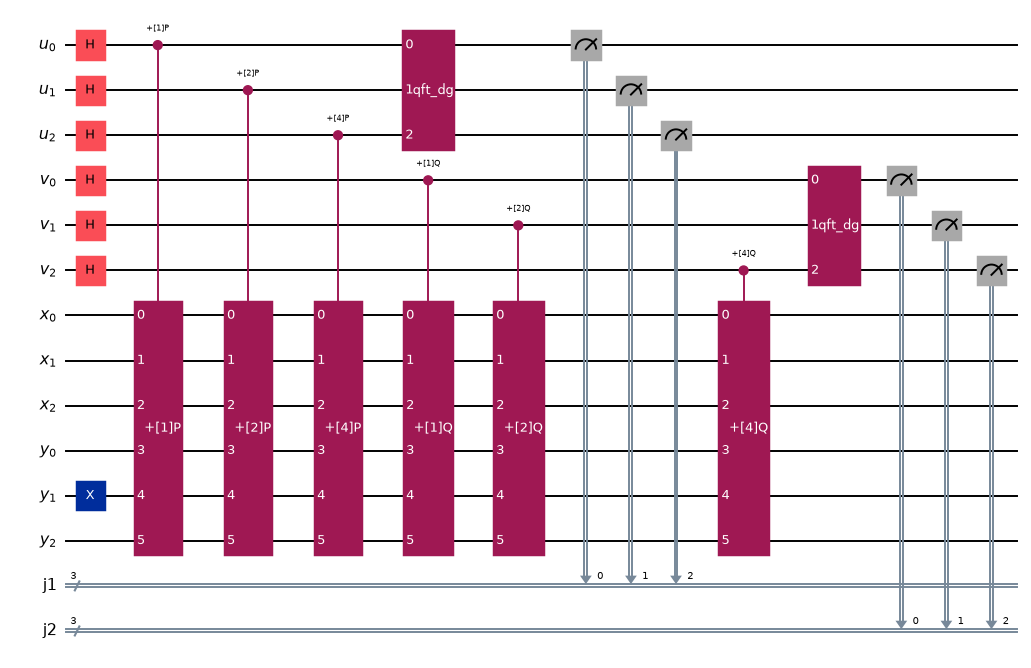

In [36]:
def boxed_ecdlp(curve, P, Q, order):
    qc0, info = S.ecdlp_circuit(curve, P, Q, order, oracle="table")
    n, mb, S0 = info["n"], info["m_bits"], info["offset"]
    kr, lr, px, py = QuantumRegister(mb, "u"), QuantumRegister(mb, "v"), QuantumRegister(n, "x"), QuantumRegister(n, "y")
    qc = QuantumCircuit(kr, lr, px, py, ClassicalRegister(mb, "j1"), ClassicalRegister(mb, "j2"))
    for i in range(n):
        if (S0.x >> i) & 1: qc.x(px[i])
        if (S0.y >> i) & 1: qc.x(py[i])
    qc.h(kr); qc.h(lr)
    for reg, base, name in ((kr, P, "P"), (lr, Q, "Q")):
        for i in range(mb):
            R_ = curve.mul(1 << i, base)
            g = cbox(f"+[{1 << i}]{name}", 1, 2 * n,
                     lambda q, b, R_=R_: S.permutation(q, b[1:], S.point_perm(curve, R_, n), ctrls=[b[0]]))
            qc.append(g, [reg[i], *px, *py])
    qc.append(qft(mb).inverse(), kr); qc.append(qft(mb).inverse(), lr)
    qc.measure(kr, qc.cregs[0]); qc.measure(lr, qc.cregs[1])
    return qc, info

bq, binfo = boxed_ecdlp(curve, G, Q, r)
print(f"offset S = ({binfo['offset'].x}, {binfo['offset'].y}); {bq.num_qubits} qubits")
bq.draw("mpl", scale=0.7, fold=-1)

Here each $A_R$ is a **permutation oracle**, an explicit product of transpositions over the
toy curve's points. It is the same circuit shape as the real arithmetic, and it fits in 12 qubits,
so Aer runs it with genuine superposition. The exact distribution is again a closed form
(`shor_stats.ecdlp_probs`): the sum over the lattice $u+kv\equiv z \pmod r$.

12 qubits; TVD from exact 0.031 (bound 0.054); one shot yields k: P = 0.611 exact, 0.610 measured


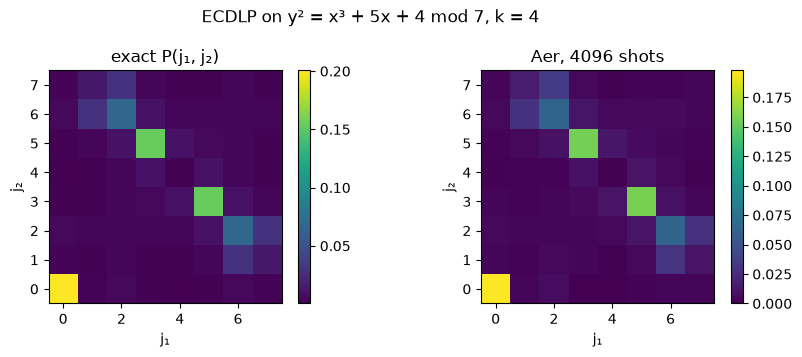

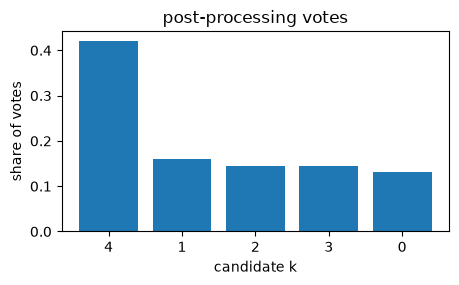

recovered k = 4; [k]G == Q: True


In [37]:
counts, cands, info = S.run_ecdlp(curve, G, Q, r, shots=4096, seed=7)
mb = info["m_bits"]; q_ = 1 << mb
pairs = S.pair_counts(counts)
exact = ST.ecdlp_probs(r, k_true, mb)
emp = ST.empirical(pairs, (q_, q_))
hit = ST.ecdlp_success_mask(r, k_true, mb)
print(f"{info['qubits']} qubits; TVD from exact {ST.tvd(emp, exact):.3f} (bound {ST.tvd_null(exact, 4096):.3f}); "
      f"one shot yields k: P = {exact[hit].sum():.3f} exact, {emp[hit].sum():.3f} measured")
plot_pairs(exact, pairs, title=f"ECDLP on y² = x³ + 5x + 4 mod 7, k = {k_true}")

total = sum(w for _, w in cands)
fig, ax = plt.subplots(figsize=(5, 2.6))
ax.bar([str(kk) for kk, _ in cands], [w / total for _, w in cands]); ax.set_xlabel("candidate k"); ax.set_ylabel("share of votes")
ax.set_title("post-processing votes"); plt.show()
found = next(kk for kk, _ in cands if C.verify_dlog(curve, G, Q, kk))
print(f"recovered k = {found}; [k]G == Q: {C.verify_dlog(curve, G, Q, found)}")

### 5.1 The real oracle: point addition as a product of modular arithmetic

With real arithmetic, $\Lambda_q(A_R)$ for a classical $R=(x_2,y_2)$ is [2026/106] Algorithm 3: eleven
reversible steps on the accumulator $(x,y)$ and a scratch $\lambda$, each a unitary built from adders,
multipliers and one **modular division** (Kaliski's algorithm):

$$\Lambda_q(A_R)=U_{11}U_{10}\cdots U_2U_1,\qquad \lambda=\frac{y_1-y_2}{x_1-x_2},\quad x_3=\lambda^2-x_1-x_2,\quad y_3=\lambda(x_2-x_3)-y_2 .$$

Step 8 is the same division as step 3, and by then it *clears* $\lambda$, because
$y/x=\lambda$ again. So the addition is in place, with no garbage. Replaying the eleven library calls one at
a time shows where the Toffolis go (p = 7):

In [38]:
import ec_kaliski as K, ec_modarith as MA, ec_mult as MU, ec_pointadd as PA
from ec_sim import Machine, getv, setv, simulate

p, n = 7, 3
x2, y2 = G.x, G.y                                          # add R = G
mch = Machine("and")
qb = mch.alloc(1, "q")[0]; x1, y1 = mch.alloc(n, "x"), mch.alloc(n, "y"); lam = mch.anc(n, "lam")
steps = [("1  x ← x1 − x2", lambda: MA.modsub_const(mch, x1, x2, p)),
         ("2  y ← y1 − q·y2", lambda: MA.cmodsub_const(mch, qb, y1, y2, p)),
         ("3  λ ← q·y / x  (division)", lambda: K.mod_div(mch, qb, x1, y1, lam, p)),
         ("4  y ← y ⊕ x·λ  (= 0)", lambda: MU.modmul_xor(mch, x1, lam, y1, p)),
         ("5  x ← x + 3·x2", lambda: MA.modadd_const(mch, x1, 3 * x2 % p, p)),
         ("6  x ← x − λ²", lambda: MU.modsqr_sub(mch, lam, x1, p)),
         ("7  y ← y + x·λ", lambda: MU.modmul_add(mch, x1, lam, y1, p)),
         ("8  λ ← 0  (division)", lambda: K.mod_div(mch, qb, x1, y1, lam, p)),
         ("9  x ← −x3", lambda: PA._csub_2x2_or_x2(mch, qb, x1, x2, p)),
         ("10 y ← y3", lambda: MA.cmodsub_const(mch, qb, y1, y2, p)),
         ("11 x ← x3", lambda: MA.cmodneg(mch, qb, x1, p))]
rows = []
for lab, fn in steps:
    mark = mch.begin(); fn()
    sub = QuantumCircuit(mch.qc.qubits)
    for ci in mch.since(mark):
        sub.append(ci)
    rc_ = R.count(sub); rows.append([lab, rc_.toffoli + rc_.and_, rc_.T])
mch.free(lam)
tot = sum(r_[1] for r_ in rows)
rows = [r_ + [f"{100 * r_[1] / tot:.0f}%"] for r_ in rows]
table(rows, ["step", "Toffoli-eq", "T", "share"])

ref = Machine("and"); rq = ref.alloc(1, "q")[0]; rx, ry = ref.alloc(n, "x"), ref.alloc(n, "y")
PA.point_add_ctrl(ref, rq, rx, ry, x2, y2, p)
print(f"sum of steps = {tot}; point_add_ctrl = {R.count(ref).toffoli + R.count(ref).and_} Toffoli-eq on {ref.qc.num_qubits} qubits")

good = 0
for P1 in pts:
    if C.point_add_exceptional(curve, P1, G):
        continue
    init = {}; setv(init, [rq], 1); setv(init, rx, P1.x); setv(init, ry, P1.y)
    bits = simulate(ref.qc, init, ref.checks)
    assert (getv(bits, ref.qc, rx), getv(bits, ref.qc, ry)) == ((P3 := curve.add(P1, G)).x, P3.y)
    good += 1
print(f"P + G correct, every ancilla back to |0>, for all {good} non-exceptional points P")

| step | Toffoli-eq | T | share |
|---|---|---|---|
| 1  x ← x1 − x2 | 8 | 32 | 0% |
| 2  y ← y1 − q·y2 | 15 | 63 | 1% |
| 3  λ ← q·y / x  (division) | 1,095 | 5,154 | 40% |
| 4  y ← y ⊕ x·λ  (= 0) | 156 | 642 | 6% |
| 5  x ← x + 3·x2 | 8 | 32 | 0% |
| 6  x ← x − λ² | 167 | 686 | 6% |
| 7  y ← y + x·λ | 167 | 686 | 6% |
| 8  λ ← 0  (division) | 1,095 | 5,154 | 40% |
| 9  x ← −x3 | 11 | 44 | 0% |
| 10 y ← y3 | 15 | 63 | 1% |
| 11 x ← x3 | 7 | 28 | 0% |

sum of steps = 2744; point_add_ctrl = 2744 Toffoli-eq on 64 qubits
P + G correct, every ancilla back to |0>, for all 6 non-exceptional points P


The two divisions are ~80% of the cost, which is why both papers attack the inversion. The full
oracle is 69 qubits and ~10⁵ gates for this 5-element group, far beyond a statevector. It is a
permutation, though, so pushing basis states through it (`ec_sim`) checks it exactly:

In [39]:
from ec_sim import run as ec_run
mo, oinfo = S.ecdlp_circuit(curve, G, Q, r, oracle="arith")
kr, lr, px, py = oinfo["regs"]; S0 = oinfo["offset"]
c_ = R.count(mo)
print(f"arithmetic oracle: {c_.qubits} qubits, {len(mo.qc.data):,} gates, {c_.toffoli + c_.and_:,} Toffoli-eq, "
      f"{c_.T:,} T, {c_.rotations} rotations")
for u, v in ((1, 0), (2, 3), (5, 6)):
    acc = curve.add(curve.add(S0, curve.mul(u, G)), curve.mul(v, Q))
    rd = ec_run(mo, {kr: u, lr: v})
    print(f"  u={u}, v={v}: circuit gives ({rd(px)}, {rd(py)}), S + [u]G + [v]Q = ({acc.x}, {acc.y})")

arithmetic oracle: 69 qubits, 105,339 gates, 16,488 Toffoli-eq, 75,600 T, 0 rotations
  u=1, v=0: circuit gives (5, 0), S + [u]G + [v]Q = (5, 0)


  u=2, v=3: circuit gives (4, 5), S + [u]G + [v]Q = (4, 5)
  u=5, v=6: circuit gives (4, 5), S + [u]G + [v]Q = (4, 5)


## 6. ECDLP: complexity and optimisations

**Complexity.** Kaliski's division runs $2n$ rounds of $O(n)$ Toffolis, so $O(n^2)$, and the
multiplications are $O(n^2)$ too. One point addition is therefore $O(n^2)$ Toffolis on $O(n)$ qubits,
and Shor needs one per bit of $u$ and $v$, about $2n$ of them: **$O(n^3)$ Toffolis**. The arithmetic
contains **no rotations**. The only rotations are in the final QFT, and the semiclassical QFT turns those
into $2m$ classically controlled phases. Measured, one controlled point addition:

In [40]:
rows, pts_ = [], []
for p in (7, 13, 31, 61, 127, 251, 509, 1021):
    n = p.bit_length()
    mm = Machine("and")
    PA.point_add_ctrl(mm, mm.alloc(1, "q")[0], mm.alloc(n, "x"), mm.alloc(n, "y"), 2, 1, p)
    rc_ = R.count(mm)
    rows.append([p, n, rc_.qubits, rc_.toffoli + rc_.and_, rc_.T, 2 * n * (rc_.toffoli + rc_.and_)])
    pts_.append((n, rc_.qubits, rc_.toffoli + rc_.and_))
table(rows, ["p", "n", "qubits", "Toffoli-eq", "T", "≈ full Shor: 2n additions"])
nn = np.array([a for a, _, _ in pts_], float)
print(f"fitted: qubits ~ n^{np.polyfit(np.log(nn), np.log([b for _, b, _ in pts_]), 1)[0]:.2f}, "
      f"Toffoli ~ n^{np.polyfit(np.log(nn), np.log([c for _, _, c in pts_]), 1)[0]:.2f}  (per point addition)")

| p | n | qubits | Toffoli-eq | T | ≈ full Shor: 2n additions |
|---|---|---|---|---|---|
| 7 | 3 | 64 | 2,756 | 12,632 | 16,536 |
| 13 | 4 | 83 | 4,769 | 21,794 | 38,152 |
| 31 | 5 | 99 | 7,206 | 32,940 | 72,060 |
| 61 | 6 | 115 | 10,139 | 46,358 | 121,668 |
| 127 | 7 | 131 | 13,568 | 62,048 | 189,952 |
| 251 | 8 | 150 | 17,685 | 80,778 | 282,960 |
| 509 | 9 | 166 | 22,130 | 101,108 | 398,340 |
| 1,021 | 10 | 182 | 27,071 | 123,710 | 541,420 |

fitted: qubits ~ n^0.86, Toffoli ~ n^1.90  (per point addition)


**Optimisations implemented** (from eprint 2026/106, Kim et al., and 2026/1128, Schrottenloher),
each measured in `bench/ec_ablation.py` against a fixed task with correctness re-checked:

| optimisation | source | module |
|---|---|---|
| Gidney adder (n Toffoli, temporary ANDs) vs CDKM (2n) | [Gid18] | `ec_adders` |
| controlled addition by copy-then-add | 106 Fig 4b | `ec_adders` |
| quantum carry-save adder, word-level Montgomery multiplication | 106 §3.2 | `ec_qcsa`, `ec_montgomery` |
| Kaliski with unconditional rounds, postponed reduction, control fan-out | 106 §3.3 | `ec_kaliski_opt` |
| Jacobian–affine out-of-place point addition (no inversion) + zig-zag schedule | 106 §4.2 | `ec_proj` |
| Euclidean dialog + Bézout replay: in-place multiplication/division | 1128 §3 | `ec_eea` |
| approximate and pseudo-Mersenne modular arithmetic | 1128 §4 | `ec_approx` |
| windowed point addition | 1128 Alg 1 | `ec_window` |
| temporary AND everywhere; semiclassical QFT | [Gid18]; Griffiths–Niu | `ec_gates`; `semiclassical` |

**Not implemented:** register sharing (1128 §3.1; probabilistic), 1128's Algorithm 11, Gidney's
dirty-ancilla constant adder, the Ed25519 extension, and physical-level estimates.

| task | baseline → optimised | qubits | Toffoli | T | depth | saving | failure rate |
|---|---|---|---|---|---|---|---|
| 16-bit addition y += x | CDKM [CDKM04] → Gidney [Gid18] | 33 → 47 | 32 → 15 | 224 → 60 | 81 → 102 | 53% (Toffoli) | exact |
| 16-bit controlled addition y += x if ctrl | reconstruct (CDKM) → copy-then-add [106] Fig 4b | 34 → 64 | 64 → 31 | 448 → 124 | 81 → 119 | 52% (Toffoli) | exact |
| 16-bit modular multiplication mod 65521 | schoolbook double-and-add → Montgomery+QCSA [106] w=4 | 86 → 324 | 2,080 → 1,566 | 8,368 → 6,264 | 13,043 → 6,669 | 25% (Toffoli) | exact |
| modular inversion mod 4093 | reference Kaliski [HJN+20] → unconditional+postponed [106] | 177 → 196 | 6,585 → 4,653 | 31,740 → 23,796 | 27,239 → 16,059 | 29% (Toffoli) | exact |
| the multiplicative step of a point addition, mod 61 | Kaliski division (out-of-place) → EEA dialog + Bezout replay [1128] | 115 → 66 | 4,068 → 1,875 | 19,116 → 8,445 | 17,373 → 8,987 | 54% (Toffoli) | exact |
| one point addition on p=11 (9 pairs checked) | affine in-place [106] Alg 3 → Jacobian out-of-place [106] Alg 4 | 83 → 98 | 4,769 → 2,642 | 21,794 → 10,772 | 21,024 → 15,126 | 45% (Toffoli) | exact |
| modular doubling mod 1021 | exact (Alg 5) → pseudo-Mersenne (Alg 7) | 36 → 21 | 21 → 4 | 84 → 16 | 156 → 39 | 81% (Toffoli) | 3.1% |
| T-count of one inversion mod 4093 | all Toffoli (7 T each) → temporary AND (4 T / 0 T) | 177 → 177 | 11,322 → 6,585 | 79,254 → 31,740 | 27,239 → 27,239 | 60% (T) | exact |

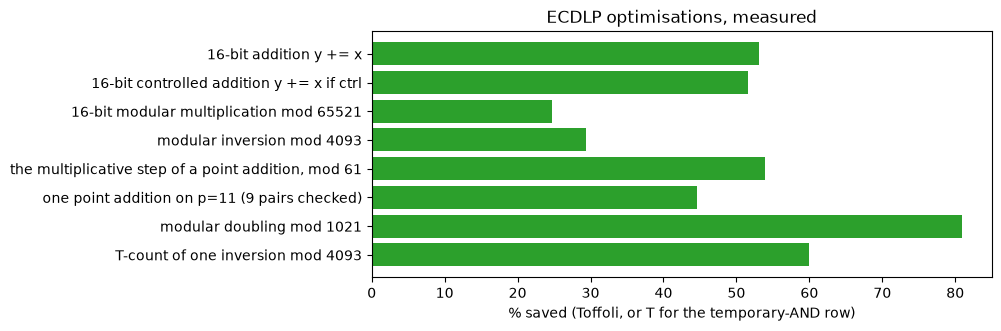

In [41]:
import json
abl = json.load(open(ROOT / "bench" / "ec_ablation.json"))
pick = [("adder_n16", "CDKM [CDKM04]", "Gidney [Gid18]"),
        ("cadder_n16", "reconstruct (CDKM)", "copy-then-add [106] Fig 4b"),
        ("mul_n16_w4", "schoolbook double-and-add", "Montgomery+QCSA [106] w=4"),
        ("inv_n12", "reference Kaliski [HJN+20]", "unconditional+postponed [106]"),
        ("inplace_n6_p61", "Kaliski division (out-of-place)", "EEA dialog + Bezout replay [1128]"),
        ("padd_p=11", "affine in-place [106] Alg 3", "Jacobian out-of-place [106] Alg 4"),
        ("moddbl_q1021", "exact (Alg 5)", "pseudo-Mersenne (Alg 7)"),
        ("tempand_n12", "all Toffoli (7 T each)", "temporary AND (4 T / 0 T)")]
rows, bars = [], []
for key, base_, opt in pick:
    e = abl[key]; b, o = e["variants"][base_], e["variants"][opt]
    metric = "t" if key.startswith("tempand") else "toffoli_paper"
    save = 1 - o[metric] / b[metric]
    rows.append([e["task"], f"{base_} → {opt}", f"{b['qubits']} → {o['qubits']}",
                 f"{b['toffoli_paper']:,} → {o['toffoli_paper']:,}", f"{b['t']:,} → {o['t']:,}",
                 f"{b['depth']:,} → {o['depth']:,}", f"{100 * save:.0f}% ({'T' if metric == 't' else 'Toffoli'})",
                 f"{o['failure_rate']:.1%}" if o["failure_rate"] else "exact"])
    bars.append((e["task"], save))
table(rows, ["task", "baseline → optimised", "qubits", "Toffoli", "T", "depth", "saving", "failure rate"])

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh([b_[0] for b_ in bars], [100 * b_[1] for b_ in bars], color="tab:green"); ax.invert_yaxis()
ax.set_xlabel("% saved (Toffoli, or T for the temporary-AND row)"); ax.set_title("ECDLP optimisations, measured"); plt.show()

Two of these, live. First **Gidney's adder**: each carry is an AND into a clean qubit (the
`ecand` boxes, 4 T), and the uncompute (`ecand_dg`) is measurement-based (0 T). Second, **Kaliski
inversion**, reference against 106's optimised version, checked on every input mod 31. The optimised
one returns the Montgomery form $x^{-1}2^{2n}$:

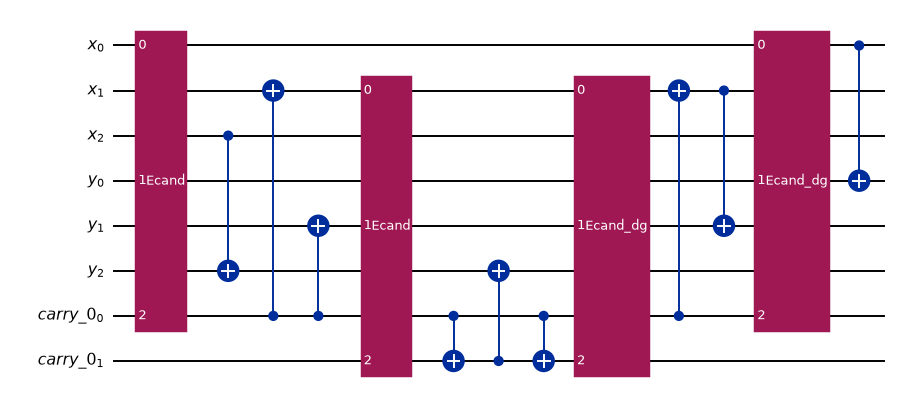

| inversion mod 31 | qubits | Toffoli | T (Toffoli = 7T) | T (temporary AND) | CP gates | small rotations | T incl. rotations (ε = 10⁻³) |
|---|---|---|---|---|---|---|---|
| reference Kaliski [HJN+20] | 83 | 1,242 | 5,958 | 5,958 | 0 | 0 | 5,958 |
| 106 §3.3: unconditional + postponed | 84 | 817 | 4,168 | 4,168 | 0 | 0 | 4,168 |

reference correct on all x: True;  optimised correct on all x: True


In [42]:
import ec_adders as EA, ec_kaliski_opt as KO
ga = Machine("and"); gx, gy = ga.alloc(3, "x"), ga.alloc(3, "y"); gan = ga.anc(2, "carry")
EA.gidney_add(ga.ctx, gx, gy, gan); ga.free(gan)
display(ga.qc.draw("mpl", scale=0.7, fold=-1))

p, n = 31, 5
mr = Machine("and"); xr, orr = mr.alloc(n, "x"), mr.alloc(n, "o"); K.mod_inv(mr, xr, orr, p)
mo_ = Machine("and"); xo, oo = mo_.alloc(n, "x"), mo_.alloc(n, "o"); KO.mod_inv_mont(mo_, xo, oo, p)
ok_r = all(ec_run(mr, {xr: x})(orr) == pow(x, -1, p) for x in range(1, p))
ok_o = all(ec_run(mo_, {xo: x})(oo) == pow(x, -1, p) * pow(2, 2 * n, p) % p for x in range(1, p))
table([cost("reference Kaliski [HJN+20]", mr.qc), cost("106 §3.3: unconditional + postponed", mo_.qc)], ["inversion mod 31"] + COST)
print(f"reference correct on all x: {ok_r};  optimised correct on all x: {ok_o}")

### 6.1 The semiclassical ECDLP circuit on Aer

The same `semiclassical_iqft` loop, run once per scalar register, needs one counting qubit for both,
7 qubits instead of 12 at $p=7$ and 9 instead of 16 at $p=11$. That is the assumption behind both
papers counting only the point arithmetic. On the 13-point group of $y^2=x^3+x+6 \bmod 11$:

9 qubits (full registers: 16); 0.6s; TVD 0.071 (bound 0.084); one shot yields k: P = 0.639 exact, 0.634 measured


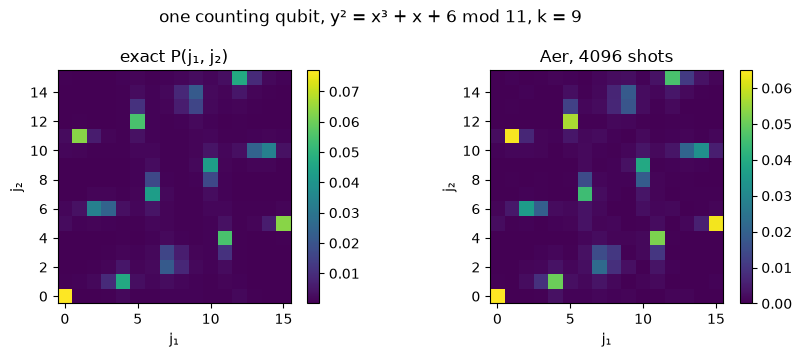

top candidates: [(9, 0.305), (4, 0.068), (6, 0.063)] -> k = 9


In [43]:
curve11, G11 = C.TOY11, C.TOY11_G
r11 = curve11.point_order(G11); k11 = 9; Q11 = curve11.mul(k11, G11)
full_q = S.ecdlp_circuit(curve11, G11, Q11, r11, oracle="table")[1]["qubits"]
t0 = time.time()
counts11, cands11, info11 = S.run_ecdlp(curve11, G11, Q11, r11, shots=4096, seed=11, one_control=True)
dt = time.time() - t0
mb11 = info11["m_bits"]; q11 = 1 << mb11
ex11 = ST.ecdlp_probs(r11, k11, mb11); pr11 = S.pair_counts(counts11); em11 = ST.empirical(pr11, (q11, q11))
hit11 = ST.ecdlp_success_mask(r11, k11, mb11)
print(f"{info11['qubits']} qubits (full registers: {full_q}); {dt:.1f}s; TVD {ST.tvd(em11, ex11):.3f} "
      f"(bound {ST.tvd_null(ex11, 4096):.3f}); one shot yields k: P = {ex11[hit11].sum():.3f} exact, {em11[hit11].sum():.3f} measured")
plot_pairs(ex11, pr11, title=f"one counting qubit, y² = x³ + x + 6 mod 11, k = {k11}")
print("top candidates:", [(kk, round(w / sum(w_ for _, w_ in cands11), 3)) for kk, w in cands11[:3]],
      "-> k =", next(kk for kk, _ in cands11 if C.verify_dlog(curve11, G11, Q11, kk)))

### 6.2 At cryptographic size: the papers' own formulas

Nothing here builds a 256-bit point addition. These are the papers' formulas evaluated at their
parameters (`ec_cost`), shown for scale and **not verified** by this package:

In [44]:
import ec_cost as CO
rows = []
for n_ in (256, 384, 521):
    w = 11 if n_ <= 256 else 13
    adds, zz = CO.proj_106_additions(n_, w)
    rows.append([n_, w, adds, zz, CO.proj_1128_qubits(n_, "space"), CO.proj_1128_qubits(n_, "gate")])
table(rows, ["n", "window w", "windowed point additions [106]", "zig-zag registers [106]",
             "qubits, space-optimised [1128]", "qubits, gate-optimised [1128]"])
print(f"[1128] eq. (1), secp256k1: 2^{math.log2(CO.proj_1128_shor_toffoli()):.2f} Toffolis for the whole of Shor")
print("(1128's Table 1 reports 1192 / 1446 qubits for secp256k1; the closed form 4.355n + O(√n) above omits lower-order terms)")

| n | window w | windowed point additions [106] | zig-zag registers [106] | qubits, space-optimised [1128] | qubits, gate-optimised [1128] |
|---|---|---|---|---|---|
| 256 | 11 | 48 | 10 | 1,151 | 1,407 |
| 384 | 13 | 60 | 11 | 1,717 | 2,101 |
| 521 | 13 | 82 | 13 | 2,321 | 2,842 |

[1128] eq. (1), secp256k1: 2^26.11 Toffolis for the whole of Shor
(1128's Table 1 reports 1192 / 1446 qubits for secp256k1; the closed form 4.355n + O(√n) above omits lower-order terms)


## 7. Summary

| | factoring (Beauregard, as built) | ECDLP (affine, as built) |
|---|---|---|
| group operation | modular multiplication, $2n$ modular additions | point addition: 2 divisions + 3 products |
| qubits | $4n+2$, or $2n+3$ with one counting qubit | $O(n)$: 64 → 182 for one addition as $n$ = 3 → 10; counting registers → 1 qubit |
| Toffolis | $8n^3+22n^2$ | $O(n^2)$ per addition × $2n$ additions $=O(n^3)$ |
| small rotations | $\approx60n^4$: the dominant fault-tolerant cost | none in the arithmetic |
| the fix | Toffoli arithmetic (CDKM, lookups), windowing, coset representation, semiclassical QFT | better inversion (Kaliski opt., dialog), projective or windowed additions, temporary ANDs |

**Reproduce and verify:**

```bash
./run_tests.sh fast    # includes test_semiclassical and test_resources
./run_tests.sh full    # + end-to-end factoring, incl. the one-counting-qubit circuit
./run_tests.sh ec      # the ECDLP suite, incl. its distribution tests
./venv/bin/python examples/toy_demo.py    # toy RSA and ECDLP keys broken on Aer
```